## Problem Statement

### Context

AllLife Bank is a US bank that has a growing customer base. The majority of these customers are liability customers (depositors) with varying sizes of deposits. The number of customers who are also borrowers (asset customers) is quite small, and the bank is interested in expanding this base rapidly to bring in more loan business and in the process, earn more through the interest on loans. In particular, the management wants to explore ways of converting its liability customers to personal loan customers (while retaining them as depositors).

A campaign that the bank ran last year for liability customers showed a healthy conversion rate of over 9% success. This has encouraged the retail marketing department to devise campaigns with better target marketing to increase the success ratio.

You as a Data scientist at AllLife bank have to build a model that will help the marketing department to identify the potential customers who have a higher probability of purchasing the loan.

### Objective

To predict whether a liability customer will buy personal loans, to understand which customer attributes are most significant in driving purchases, and identify which segment of customers to target more.

### Data Dictionary
* `ID`: Customer ID
* `Age`: Customer’s age in completed years
* `Experience`: #years of professional experience
* `Income`: Annual income of the customer (in thousand dollars)
* `ZIP Code`: Home Address ZIP code.
* `Family`: the Family size of the customer
* `CCAvg`: Average spending on credit cards per month (in thousand dollars)
* `Education`: Education Level. 1: Undergrad; 2: Graduate;3: Advanced/Professional
* `Mortgage`: Value of house mortgage if any. (in thousand dollars)
* `Personal_Loan`: Did this customer accept the personal loan offered in the last campaign? (0: No, 1: Yes)
* `Securities_Account`: Does the customer have securities account with the bank? (0: No, 1: Yes)
* `CD_Account`: Does the customer have a certificate of deposit (CD) account with the bank? (0: No, 1: Yes)
* `Online`: Do customers use internet banking facilities? (0: No, 1: Yes)
* `CreditCard`: Does the customer use a credit card issued by any other Bank (excluding All life Bank)? (0: No, 1: Yes)

## Importing necessary libraries

In [ ]:
# Installing the libraries
%pip install numpy pandas matplotlib seaborn scikit-learn sklearn-pandas zipcodes -q --user

**Note**:

1. After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab), write the relevant code for the project from the next cell, and run all cells sequentially from the next cell.

2. On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [2]:
# importing the required libraries
# data manipulation and analysis
import pandas as pd
import numpy as np

# data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# to split data for model training and testing
from sklearn.model_selection import train_test_split

# machine learning algorithms
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

# evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
)

# zipcodes
import zipcodes as zcode

# supress warnings
import warnings
warnings.filterwarnings("ignore")

## Loading the dataset

In [3]:
# loading data from a CSV file into a pandas DataFrame
customer_data = pd.read_csv("Loan_Modelling.csv")

# create a copy of the original data to preserve it
data = customer_data.copy()

## Data Overview

* Observations
* Sanity checks

### First and last 5 rows in the dataset

In [4]:
# view first 5 rows of the dataset
data.head()

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


In [5]:
# view last 5 rows of the dataset
data.tail()

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
4995,4996,29,3,40,92697,1,1.9,3,0,0,0,0,1,0
4996,4997,30,4,15,92037,4,0.4,1,85,0,0,0,1,0
4997,4998,63,39,24,93023,2,0.3,3,0,0,0,0,0,0
4998,4999,65,40,49,90034,3,0.5,2,0,0,0,0,1,0
4999,5000,28,4,83,92612,3,0.8,1,0,0,0,0,1,1


### Shape of the Dataset

In [6]:
# check the shape of the dataset
data.shape

(5000, 14)

* There are 5000 rows and 14 columns in the dataset.

### Dataset Summary

In [7]:
# check the data types of each column
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIPCode             5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal_Loan       5000 non-null   int64  
 10  Securities_Account  5000 non-null   int64  
 11  CD_Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


* All variables are numerical.

* **ZIPCodes** are in numerical format, but should treated as categorical variables. we can handle this in data pre-processing.

* **Education, Personal_Loan, Securities_Account, CD_Account, Online and CreditCard** are interpreted as numerical. However, they are categorical variables which are encoded by default.

* There are no missing values in the dataset.

### Statistical Summary

In [8]:
# display the statistical summary of the dataset
data.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
ID,5000.0,2500.500000,1443.520003,1.0,1250.75,2500.5,3750.25,5000.0
Age,5000.0,45.338400,11.463166,23.0,35.00,45.0,55.00,67.0
Experience,5000.0,20.104600,11.467954,-3.0,10.00,20.0,30.00,43.0
Income,5000.0,73.774200,46.033729,8.0,39.00,64.0,98.00,224.0
ZIPCode,5000.0,93169.257000,1759.455086,90005.0,91911.00,93437.0,94608.00,96651.0
Family,5000.0,2.396400,1.147663,1.0,1.00,2.0,3.00,4.0
CCAvg,5000.0,1.937938,1.747659,0.0,0.70,1.5,2.50,10.0
Education,5000.0,1.881000,0.839869,1.0,1.00,2.0,3.00,3.0
Mortgage,5000.0,56.498800,101.713802,0.0,0.00,0.0,101.00,635.0
Personal_Loan,5000.0,0.096000,0.294621,0.0,0.00,0.0,0.00,1.0


* **ID**: The IDs are unique and sequential starting from 1 to 5000. We can drop the column.

* **Age**: Average age of customers is ~45 years ranging between 23 to 67 years. 75% of customers are under 55 years of age.

* **Experience**: Average professional experience of customers is ~20 years and 75% of the customers have greater than 10 years of experience. However, there are negative values in experience column which requires to be treated appropriately.

* **Income**: Average income of the customers is ~73K dollars per annum. However, 50% of the customers have income less than 64K dollars and standard deviation is ~46. There might be potential outliers in income data.

* **Family**: Average family size is ~2 with a max of 4 members per family.

* **CCAvg**: Average credit card spend across all customers is ~2k per month and 75% of the customers spent less than 2.5K dollars per month.

* **Mortgage**: Most customers in the dataset (>50%) have no mortgage. There is high standard deviation indicating high variability in Mortgage among those customers who have it. 25% of the customers have mortgage ranging from 101K to 635K, the Mortgage is skewed and may contain potential outliers.

### Missing Values

In [9]:
# verify missing values in the dataset
data.isnull().sum()

ID                    0
Age                   0
Experience            0
Income                0
ZIPCode               0
Family                0
CCAvg                 0
Education             0
Mortgage              0
Personal_Loan         0
Securities_Account    0
CD_Account            0
Online                0
CreditCard            0
dtype: int64

* There are no missing values in the dataset.

### Duplicate Records

In [10]:
# number of duplicates in the dataset
data.duplicated().sum()

np.int64(0)

* There are no duplicates in the dataset.

## Data Pre-Processing

### ID Column

In [11]:
# id column is not required and can be dropped
data.drop(columns=["ID"], axis=1, inplace=True)

### Treating negative values in Experience

In [12]:
# checking for negative values in 'Experience' column
data[data['Experience']<0]['Experience'].value_counts()

Experience
-1    33
-2    15
-3     4
Name: count, dtype: int64

* We have minimal number of negative values, assuming they might be typos we can replace with absolute values.

In [13]:
# replace negative values in 'Experience' with absoulte values
data['Experience'] = data['Experience'].apply(lambda x: abs(x))

In [14]:
# verifying for negative experience after imputation
data[data["Experience"] < 0]["Experience"].unique()

array([], dtype=int64)

In [15]:
# check null values after imputation
data['Experience'].isnull().sum()

np.int64(0)

### Feature Engineering

#### Processing ZIP Codes

In [16]:
# get a list of unique ZIPCodes in the dataset
unique_zipcodes = data['ZIPCode'].unique()
print(f"Number of Unique ZIPCodes in dataset: {len(unique_zipcodes)}")

Number of Unique ZIPCodes in dataset: 467


In [17]:
# creating a dict with ZIPCode as key and corresponding city as value
zip_city_dict = {}
for zipcode in unique_zipcodes:
    info = zcode.matching(zipcode.astype(str))
    if info:
        city = info[0]['city']
        zip_city_dict[zipcode] = city
    else:
        zip_city_dict[zipcode] = np.nan

# converting the dict to a DataFrame
zip_city_df = pd.DataFrame.from_dict(zip_city_dict, orient='index', columns=['City']).reset_index().rename(columns={'index':'ZIPCode'})
print(f"Number of unique cities: {zip_city_df['City'].nunique()}")
print(f"Number of records with missing city information: {zip_city_df['City'].isnull().sum()}")
zip_city_df.head()

Number of unique cities: 244
Number of records with missing city information: 4


,ZIPCode,City
0,91107,Pasadena
1,90089,Los Angeles
2,94720,Berkeley
3,94112,San Francisco
4,91330,Northridge


In [18]:
# creating a dict with ZIPCode as key and corresponding county as value
zip_county_dict = {}
for zipcode in unique_zipcodes:
    info = zcode.matching(zipcode.astype(str))
    if info:
        county = info[0]['county']
        zip_county_dict[zipcode] = county
    else:
        zip_county_dict[zipcode] = np.nan

# converting the dict to a DataFrame
zip_county_dict = pd.DataFrame.from_dict(zip_county_dict, orient='index', columns=['County']).reset_index().rename(columns={'index':'ZIPCode'})
print(f"Number of unique counties: {zip_county_dict['County'].nunique()}")
print(f"Number of records with missing county information: {zip_county_dict['County'].isnull().sum()}")
zip_county_dict.head()

Number of unique counties: 38
Number of records with missing county information: 4


,ZIPCode,County
0,91107,Los Angeles County
1,90089,Los Angeles County
2,94720,Alameda County
3,94112,San Francisco County
4,91330,Los Angeles County


* Relacing ZIPCodes with Counties gives the better grouping (38 unique counties) compared to Cities (244 unique values).

In [19]:
# checking the missing values in county data
missing_county_zip = zip_county_dict[zip_county_dict['County'].isnull()]
missing_county_zip

,ZIPCode,County
79,92717,NaN
210,93077,NaN
236,92634,NaN
276,96651,NaN


* As per manual validation on USPS website, all 4 of these ZIPCodes are invalid.

In [20]:
# checking the records with missing county information in the original dataset
invalid_zip_records = data[data['ZIPCode'].isin(zip_county_dict[zip_county_dict['County'].isnull()]['ZIPCode'])]
print(f"Number of records with invalid ZIPCodes: {invalid_zip_records.shape[0]}")
print(f"Percent of total records: {invalid_zip_records.shape[0]/data.shape[0]*100:.2f}%")
invalid_zip_records.describe().T

Number of records with invalid ZIPCodes: 34
Percent of total records: 0.68%


,count,mean,std,min,25%,50%,75%,max
Age,34.0,43.088235,11.468977,24.0,33.250,42.5,51.00,65.0
Experience,34.0,18.000000,11.238462,0.0,8.500,17.5,25.75,40.0
Income,34.0,65.941176,44.736224,9.0,31.750,53.0,99.25,171.0
ZIPCode,34.0,93409.617647,1524.663182,92634.0,92717.000,92717.0,92717.00,96651.0
Family,34.0,2.294118,1.168511,1.0,1.000,2.0,3.00,4.0
CCAvg,34.0,2.072647,2.255696,0.1,0.525,1.3,2.55,7.8
Education,34.0,1.970588,0.797165,1.0,1.000,2.0,3.00,3.0
Mortgage,34.0,31.676471,73.326055,0.0,0.000,0.0,0.00,301.0
Personal_Loan,34.0,0.088235,0.287902,0.0,0.000,0.0,0.00,1.0
Securities_Account,34.0,0.147059,0.359491,0.0,0.000,0.0,0.00,1.0


* Even though the percentage of records with invalid zipcodes is minimal, we have some useful information. 

In [21]:
# map county names to the original dataset
data = data.merge(zip_county_dict, on='ZIPCode', how='left')

# keep county as ZipCode for invalid ZIPCodes
data['County'] = data.apply(lambda row: row['ZIPCode'] if pd.isnull(row['County']) else row['County'], axis=1)

# drop the ZIPCode column as we have replaced it with County
data.drop(columns=['ZIPCode'], axis=1, inplace=True)

data.head()

,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard,County
0,25,1,49,4,1.6,1,0,0,1,0,0,0,Los Angeles County
1,45,19,34,3,1.5,1,0,0,1,0,0,0,Los Angeles County
2,39,15,11,1,1.0,1,0,0,0,0,0,0,Alameda County
3,35,9,100,1,2.7,2,0,0,0,0,0,0,San Francisco County
4,35,8,45,4,1.0,2,0,0,0,0,0,1,Los Angeles County


In [22]:
# re-verify missing values in the dataset
data.isnull().sum()


Age                   0
Experience            0
Income                0
Family                0
CCAvg                 0
Education             0
Mortgage              0
Personal_Loan         0
Securities_Account    0
CD_Account            0
Online                0
CreditCard            0
County                0
dtype: int64

## Exploratory Data Analysis.

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

### Univariate Analysis

#### Numerical Features

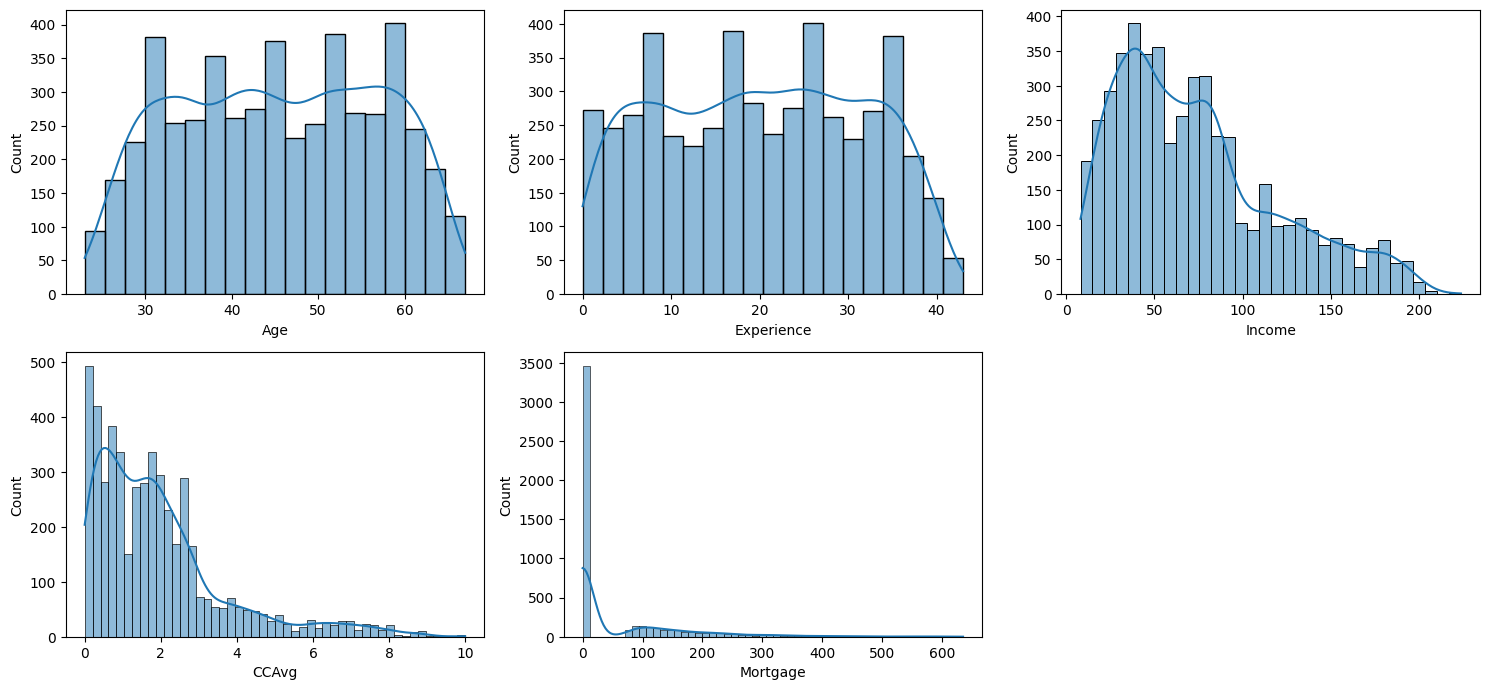

In [23]:
# defining the figure size
plt.figure(figsize=(15, 10))

# defining the list of numerical features to plot
num_features = ['Age', 'Experience', 'Income', 'CCAvg', 'Mortgage']

# plotting the histogram for each numerical feature
for i, feature in enumerate(num_features):
    plt.subplot(3, 3, i+1)    # assign a subplot in the main plot
    sns.histplot(data=data, x=feature, kde=True)    # plot the histogram

plt.tight_layout();   # to add spacing between plots

* **Income**, **CCAvg (Average Credit Card Spending)** and **Mortgage** exhibit right skewed distributions

* **Age** and **Experience** exhibit approximately uniform distributions

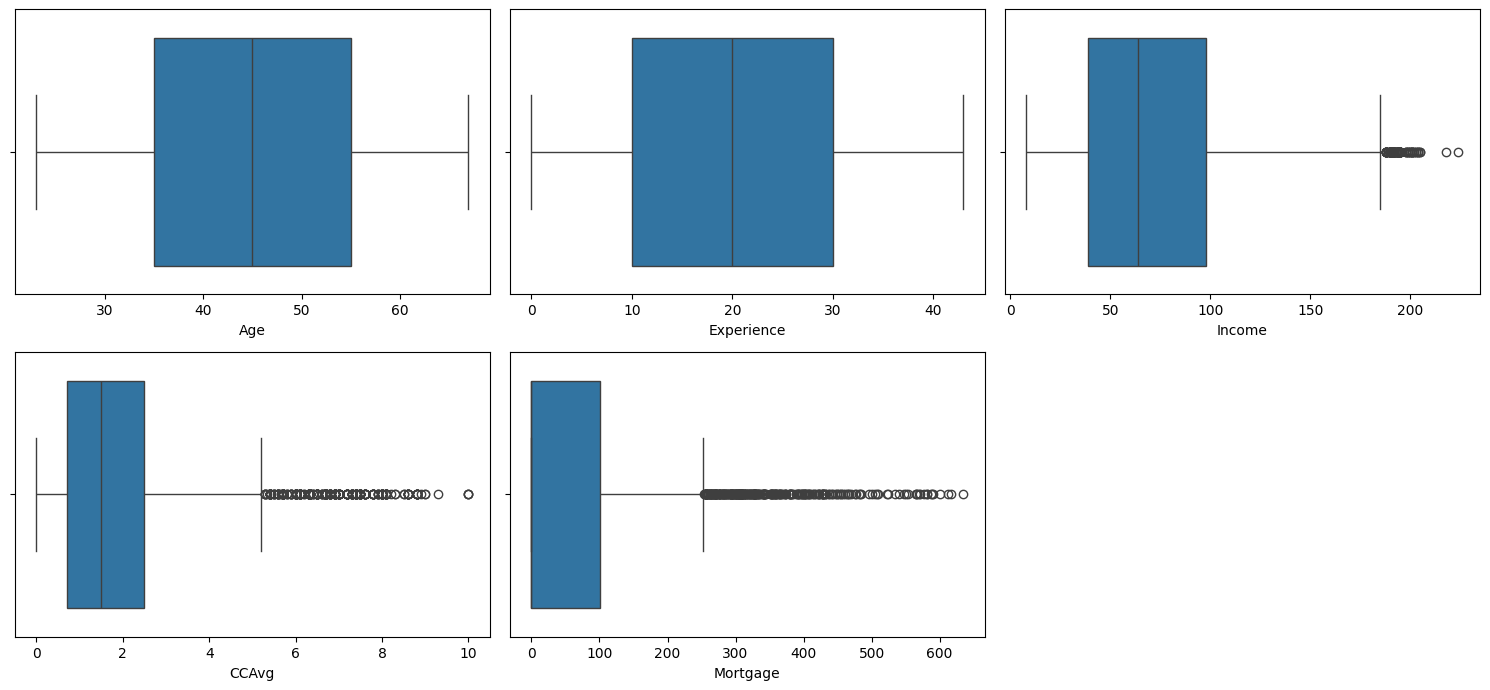

In [24]:
# defining the figure size
plt.figure(figsize=(15, 10))

# plotting the boxplot for each numerical feature
for i, feature in enumerate(num_features):
    plt.subplot(3, 3, i+1)    # assign a subplot in the main plot
    sns.boxplot(data=data, x=feature)    # plot the histogram

plt.tight_layout();    # to add spacing between plots

* There are no outliers in **Age** and **Experience**

* **Income**, **CCAvg** and **Mortgage** contains outliers

#### Categorical Features

In [25]:
# get all feature names
features = data.columns.tolist()

# get categorical features by excluding numerical features and ID
cat_features = [feat for feat in features if feat not in num_features]
print(cat_features)

['Family', 'Education', 'Personal_Loan', 'Securities_Account', 'CD_Account', 'Online', 'CreditCard', 'County']


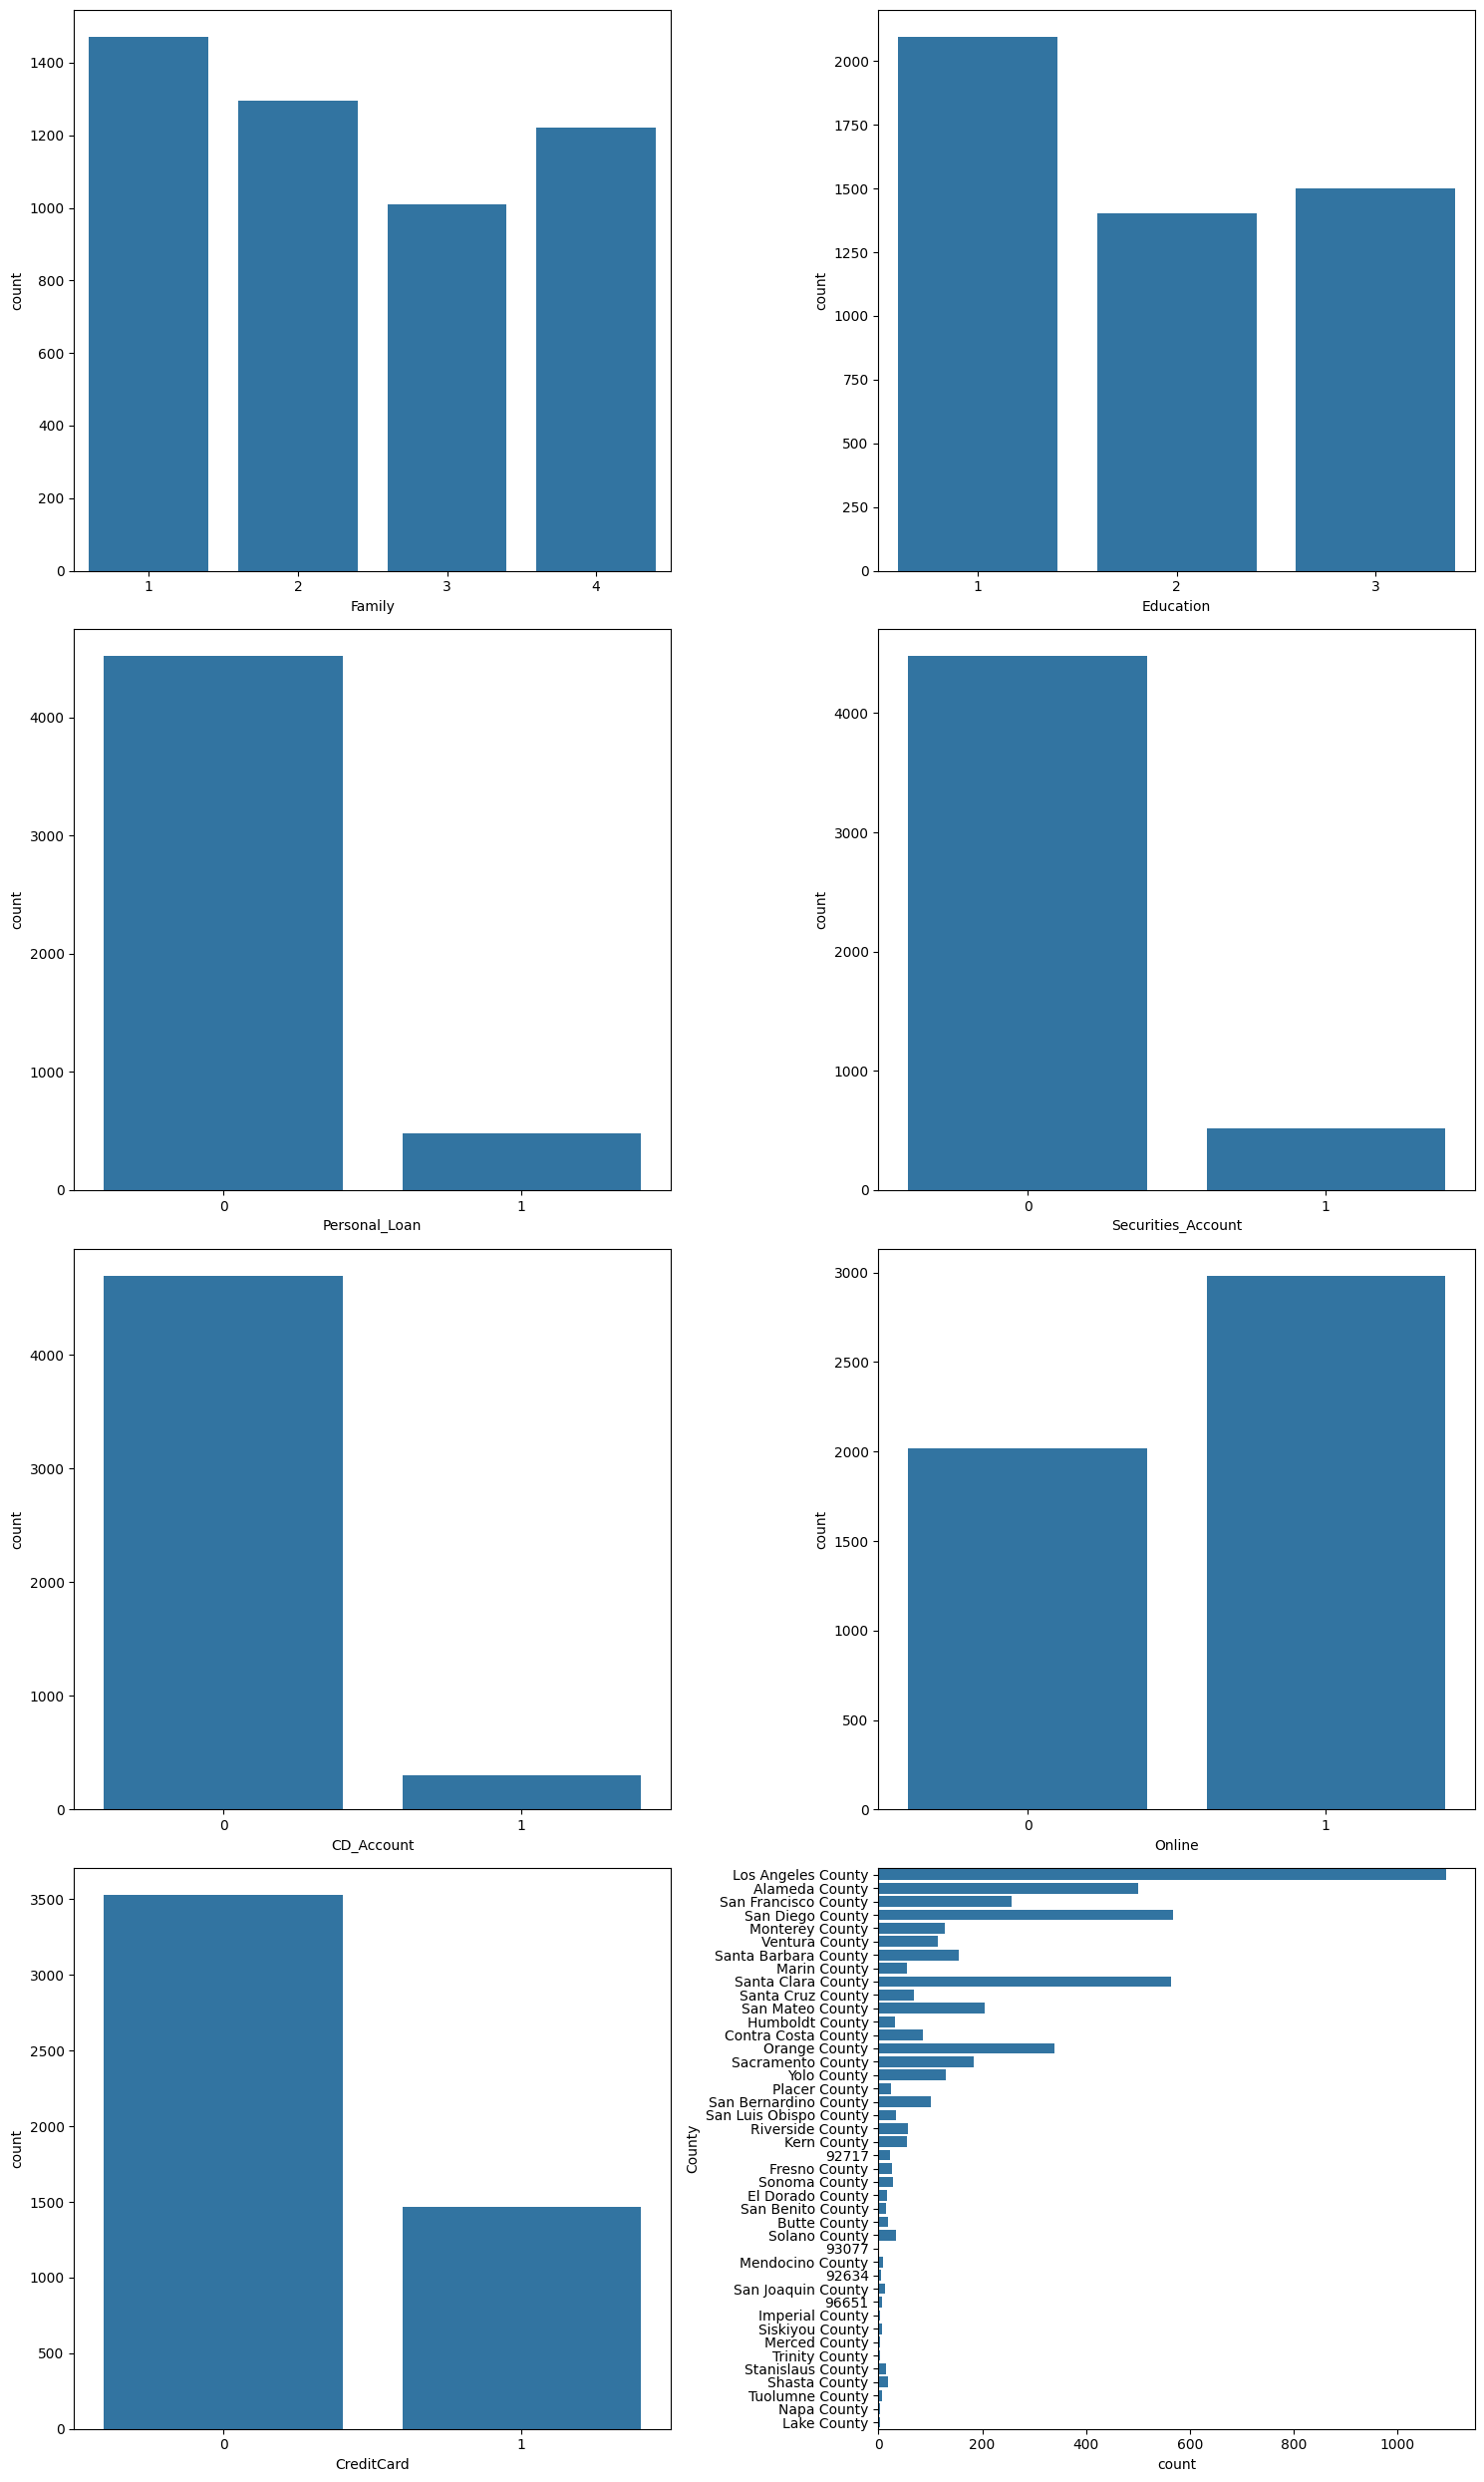

In [26]:
# defining the figure size
plt.figure(figsize=(15, 25))

# plotting the countplot for each categorical feature
for i, feature in enumerate(cat_features):
    plt.subplot(4, 2, 1+i)    # assign a subplot in the main plot
    if feature != 'County':
        sns.countplot(data=data, x=feature)    # plot the histogram
    else:
        sns.countplot(data=data, y=feature)    # plot the histogram

plt.tight_layout();    # to add spacing between plots

In [27]:
# checking the value proportions in each categorical feature
for i, feature in enumerate(cat_features):
    print(f"\nValue counts for {feature}:\n{data[feature].value_counts(normalize=True)}")


Value counts for Family:
Family
1    0.2944
2    0.2592
4    0.2444
3    0.2020
Name: proportion, dtype: float64

Value counts for Education:
Education
1    0.4192
3    0.3002
2    0.2806
Name: proportion, dtype: float64

Value counts for Personal_Loan:
Personal_Loan
0    0.904
1    0.096
Name: proportion, dtype: float64

Value counts for Securities_Account:
Securities_Account
0    0.8956
1    0.1044
Name: proportion, dtype: float64

Value counts for CD_Account:
CD_Account
0    0.9396
1    0.0604
Name: proportion, dtype: float64

Value counts for Online:
Online
1    0.5968
0    0.4032
Name: proportion, dtype: float64

Value counts for CreditCard:
CreditCard
0    0.706
1    0.294
Name: proportion, dtype: float64

Value counts for County:
County
Los Angeles County        0.2190
San Diego County          0.1136
Santa Clara County        0.1126
Alameda County            0.1000
Orange County             0.0678
San Francisco County      0.0514
San Mateo County          0.0408
Sacramento Cou

##### Categorical Feature Observations
* **Family**: The distribution of Family size is relatively balanced. Family sizes 1, 2 and 4 constitute 80% of the records in dataset with individuals being the highest proprotion with ~30%. 3 member families are the least with ~20% proportion.

* **Education**: The lowest level of Education (Undergrad) is the dominant group with ~42% customers.

* **Personal_Loan, Securities_Account, CD_Account**: These features are highly imbalanced, with CD_Account being the rarest (only 6.04% adoption), highlighting that most customers do not have these specific products. The adoption rates for Personal_Loan and Securities_Account are ~10% each.

* **Online**: ~60% of the customers use Online banking facilities.

* **CreditCard**: ~30% of the customers have Credit Cards from other banks.

* **County**: ~54% of the costomers live in **Los Angeles (~22%), San Diego (~11%), Santa Clara (~11%) and Alameda (~10%)** counties.


### Bivariate Analysis

In [28]:
# function to create a crosstab and plot a stacked bar chart

def plot_stacked_bar(data, row_feat, col_feat):
    # creating a crosstab
    tab = pd.crosstab(
        data[row_feat],
        data[col_feat].astype(str),
        normalize='index'    # normalizing by dividing each row by its row total
    )

    # Plot the stacked bar chart
    tab.plot(kind='bar', stacked=True, figsize=(7, 5))    # creating a stacked bar chart from the normalized crosstab
    plt.xlabel(row_feat);    # adding x-axis label
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1), title=col_feat);    # adding a legend for the col_feat column
    plt.show()

#### Correlation

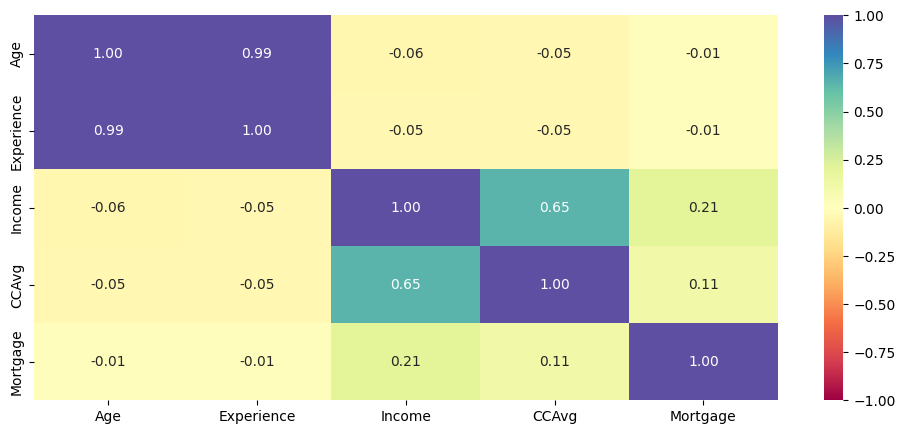

In [29]:
# defining the size of the plot
plt.figure(figsize=(12, 5))

# plotting the heatmap for correlation
sns.heatmap(
    data[num_features].corr(),annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
);

* **Age and Experience** have extremely strong positive correlation (0.99), indicating the increase of Experience with Age.

* **Income and CCAvg (Average Credit Card spend)** have relatively strong positive correlation (0.65), customers with higher income tend to spend more on Credit cards.

* **Income and Mortgage** have a weak to moderate positive correlation (0.21), indicating that customers with higher income are slightly more likely to have a higher mortgage amount.

<Figure size 1500x1500 with 0 Axes>

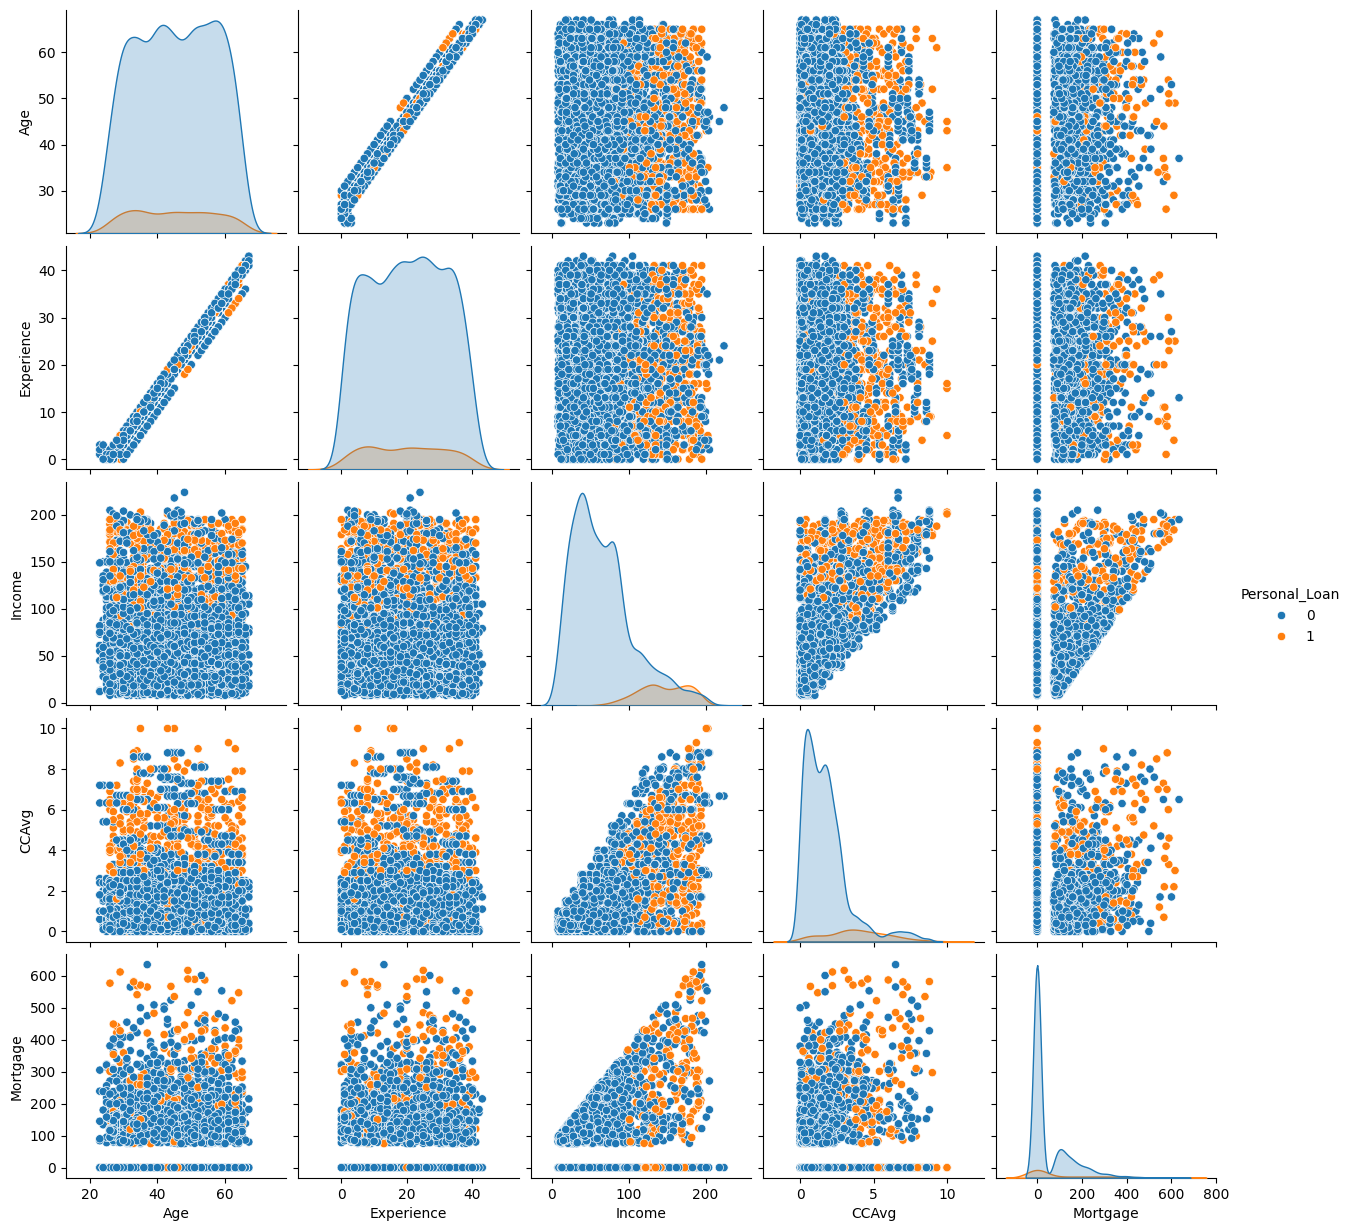

In [30]:
# Scatter plot matrix
plt.figure(figsize=(15, 15))
sns.pairplot(data, vars=num_features, hue='Personal_Loan', diag_kind='kde');

* Customers with higher income (>100K per annum) are more likely to accept a loan offer.

* Customers who spend more on Credit Cards are also likely to accept a loan offer.

* Income is the dominant factor determining whether a customer takes a personal loan followed by CCAvg.

* Age and Experience have strong and near-perfect positive correlation.

In [31]:
# dropping 'Experience' due to high correlation with 'Age' to avoid multicollinearity
data.drop(columns=['Experience'], axis=1, inplace=True)

#### Income vs Personal_Loan

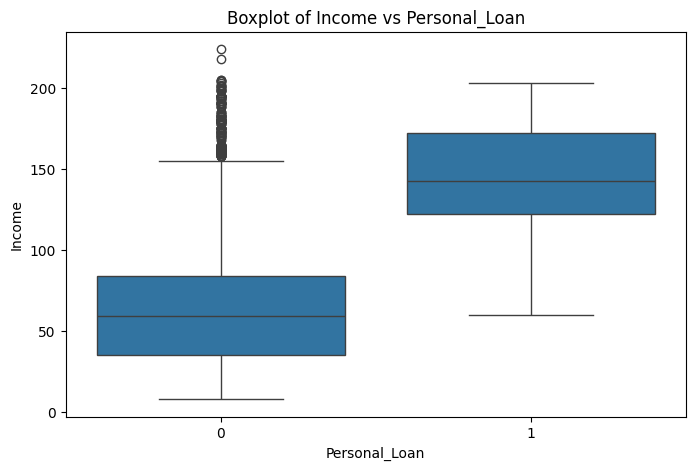

In [32]:
# boxplot of Income vs Personal_Loan
plt.figure(figsize=(8, 5))
sns.boxplot(data=data, x='Personal_Loan', y='Income')
plt.title('Boxplot of Income vs Personal_Loan')
plt.xlabel('Personal_Loan')
plt.ylabel('Income')
plt.show()

* Customers with **higher incomes** are far more likely to take a personal loan (or are more often approved for one) than those with lower incomes.

* **Outliers**: While high income is associated with taking a loan, there is a large group of very high-income individuals who choose not to take a personal loan.

* Individuals with an income in the $120k to $175k range (the IQR for group 1) are highly represented among those who took a loan, whereas the majority of those who did not take a loan have an income below $85k.

#### CCAvg vs Personal_Loan

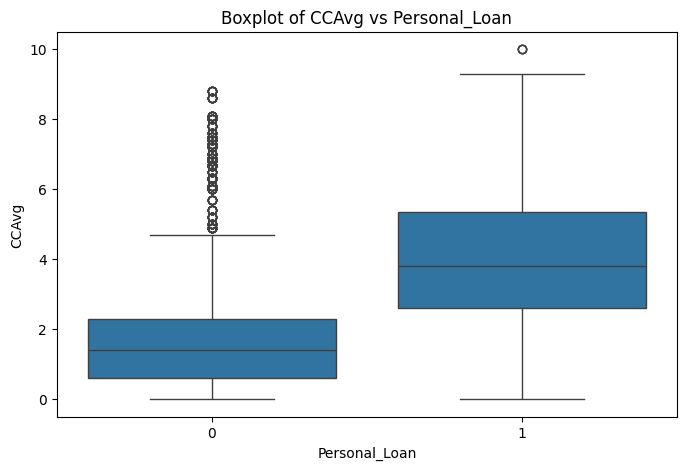

In [33]:
# boxplot of CCAvg vs Personal_Loan
plt.figure(figsize=(8, 5))
sns.boxplot(data=data, x='Personal_Loan', y='CCAvg')
plt.title('Boxplot of CCAvg vs Personal_Loan')
plt.xlabel('Personal_Loan')
plt.ylabel('CCAvg')
plt.show()

* Customers who take a personal loan tend to have significantly **higher average credit card spending** compared to those who do not.

* People who take a personal loan generally have both **higher income** (from the previous plot) and **higher average credit card spending**.

#### Family vs Personal_Loan

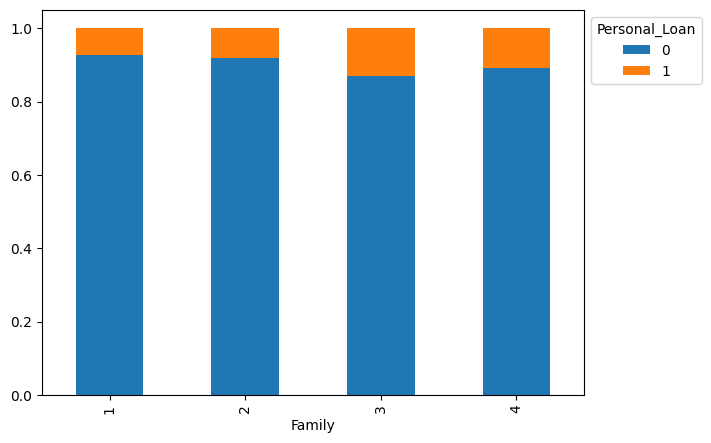

In [34]:
# creating a crosstab for Family Size vs Personal_Loan
plot_stacked_bar(data, 'Family', 'Personal_Loan')

* Customers with family size of 3 are more likely to accept the loan offer compared to others, followed by family of 4 members. 

* ~15% of customers with family size 3 accepted loan offer.

#### Education vs Personal_Loan

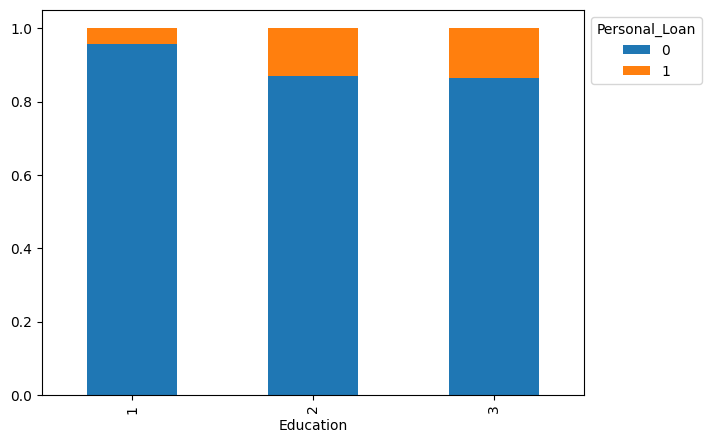

In [35]:
# creating a crosstab for Education vs Personal_Loan
plot_stacked_bar(data, 'Education', 'Personal_Loan')

* Customers with Graduate and Advanced/Professional level education are more likely to accept loan offer compared to the Undergrad customers.

#### Securities_Account vs Personal_Loan

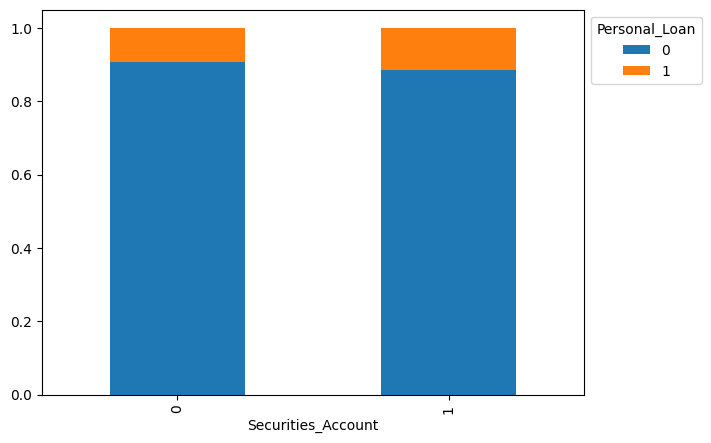

In [36]:
# creating a crosstab for Securities_Account vs Personal_Loan
plot_stacked_bar(data, 'Securities_Account', 'Personal_Loan')

* Customers with Securities_Account are slightly more likely to accept loan offer, but there is no significant difference compared to customers without Securities_Account.

#### CD_Account vs Personal_Loan

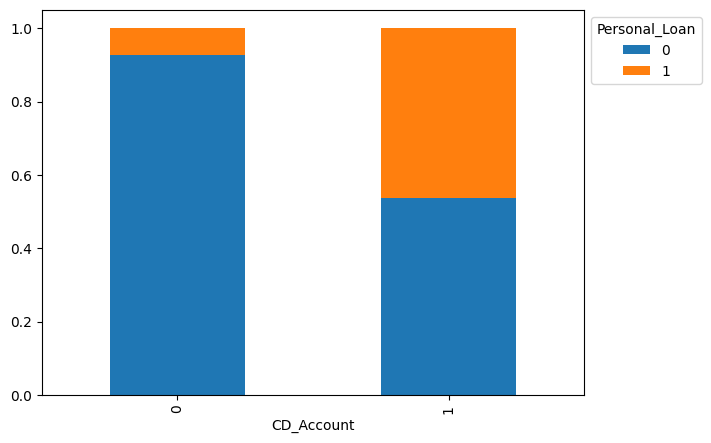

In [37]:
# creating a crosstab for CD_Account vs Personal_Loan
plot_stacked_bar(data, 'CD_Account', 'Personal_Loan')

* Customers with CD_Account are **highly likely** to accept a loan offer compared to those without CD_Account.

* ~50% of the customers with CD_Account accepted previous loan offer. This makes CD_Account significant feature for prediction.

#### Online vs Personal_Loan

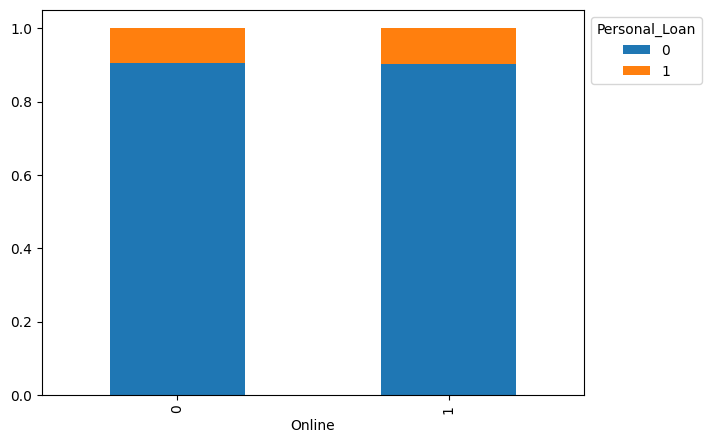

In [38]:
# creating a crosstab for Online vs Personal_Loan
plot_stacked_bar(data, 'Online', 'Personal_Loan')

* There is no significant association between the customer using the online facilities and the likelihood of taking a personal loan.

#### CreditCard vs Personal_Loan

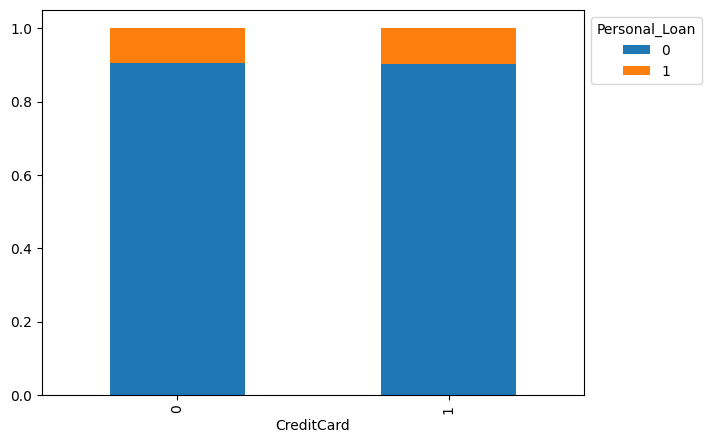

In [39]:
# creating a crosstab for CreditCard vs Personal_Loan
plot_stacked_bar(data, 'CreditCard', 'Personal_Loan')

* There is no significant association between simply having a credit card from other banks and the likelihood of taking a personal loan.

#### County vs Personal_Loan

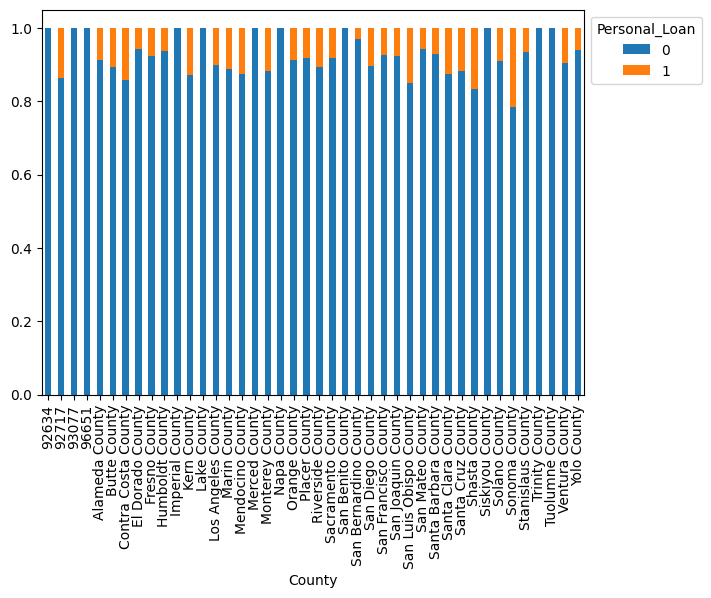

In [40]:
# creating a crosstab for County vs Personal_Loan
plot_stacked_bar(data, 'County', 'Personal_Loan')

* Proportion of customers taking a personal loan varies significantly across different counties and zip codes.

* **Top 3 areas with high likelihood of loan acceptance**:
    * Sonoma County
    * Shasta County
    * San Luis Obispo County

* **Areas with zero loan acceptance**:
    * ZIPCodes 92634, 93077 and 96651
    * Imperial County
    * Lake County
    * Merced County
    * Napa County
    * San Benito County
    * Siskiyou County
    * Trinity County
    * Tuolumne County

* This feature might be a strong predictor.

**EDA Questions**:

1. What is the distribution of mortgage attribute? Are there any noticeable patterns or outliers in the distribution?
    * Mortgage exhibits a highly right skewed distribution.
    * Vast majority of customers have no mortgage with the bank. 
    * The frequency (Count) drops off very steeply immediately after zero. This suggests that for those who do have a mortgage, the amount is usually small.
    * **Outliers**: Mortgage amounts near the maximum observed value (around 600) can be considered outliers due to their extreme distance from the highly concentrated median/mode at zero and the low frequency of the surrounding bins. These very high mortgage values are rare.

2. How many customers have credit cards?
    * 1470 customers have credit cards from other banks.

3. What are the attributes that have a strong correlation with the target attribute (personal loan)?
    * **Income, CCAvg and CD_Account** have a strong positive correlation with target attribute.
    * **Mortgage, Family Size and Education** have a moderate positive correlation with target attribute.
    * **County**: The proportion of loan takers varies significantly across different counties, meaning geography plays a role in loan aquisition success.

4. How does a customer's interest in purchasing a loan vary with their age?
    * The distribution plot for Age shows a relatively uniform distribution across the range, with a slight dip around the 35-45 age group and a slight rise around the 55-65 age group. This indicates the customers are fairly well-distributed across all adult age ranges.
    * There does not appear to be a strong linear correlation or clear age segment that is significantly more or less likely to purchase a personal loan. The interest in a personal loan seems to be independent of the customer's age.

5. How does a customer's interest in purchasing a loan vary with their education?
    * **Education Level 1 (Undergrads)**: ~5% loan acceptance. This group has the lowest interest/take-up rate for personal loans.
    * **Education Level 2 (Graduates)**: ~12% loan acceptance. This group shows a moderate increase, being more than twice as likely to take a loan as group 1.
    * **Education Level 3 (Advanced/Professional)**: ~14% loan acceptance. This group has the highest interest/take-up rate for personal loans.
    * Overall, customers with higher education levels are strongly associated with a higher probability of purchasing a personal loan.


## Data Preparation

In [41]:
# defining the explanatory (independent) and response (dependent) variables
X = data.drop(["Personal_Loan"], axis=1)
y = data["Personal_Loan"]

In [42]:
# creating dummy variables
X = pd.get_dummies(X, columns=X.select_dtypes(include=["object", "category"]).columns.tolist(), drop_first=True)

# specifying the datatype of the independent variables data frame
X = X.astype(float)

X.head()

,Age,Income,Family,CCAvg,Education,Mortgage,Securities_Account,CD_Account,Online,CreditCard,...,County_Santa Cruz County,County_Shasta County,County_Siskiyou County,County_Solano County,County_Sonoma County,County_Stanislaus County,County_Trinity County,County_Tuolumne County,County_Ventura County,County_Yolo County
0,25.0,49.0,4.0,1.6,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,45.0,34.0,3.0,1.5,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,39.0,11.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,35.0,100.0,1.0,2.7,2.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,35.0,45.0,4.0,1.0,2.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [43]:
# splitting the data in an 80:20 ratio for train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42)    # stratify ensures that the training and test sets have a similar distribution of the response variable

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (4000, 51)
Shape of X_test: (1000, 51)
Shape of y_train: (4000,)
Shape of y_test: (1000,)


## Model Building

### Model Evaluation Criterion

**Model can make wrong predictions as:**

1. False Negatives: Predicting a customer will not accept a Personal loan offer but in reality the customer would be purchasing the loan.

2. False Positives: Predicting a customer will accept a Personal loan offer but in reality the customer would not be purchasing the loan.

**Which case is more important?**

* If we predict a potential buying customer as a non-buyer (False Negatives), bank would lose an opportunity of selling personal loan to a potential customer.

**How to reduce this loss i.e need to reduce False Negatives?**
*  `recall` should be maximized, the greater the recall higher the chances of minimizing the false negatives.


### Functions to check model performance and plot confusion matrix

In [44]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [45]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

### Model Building

#### Decision Tree (Default)

In [46]:
model0 = DecisionTreeClassifier(criterion="gini", random_state=42)
model0.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


##### Model performance on Training set

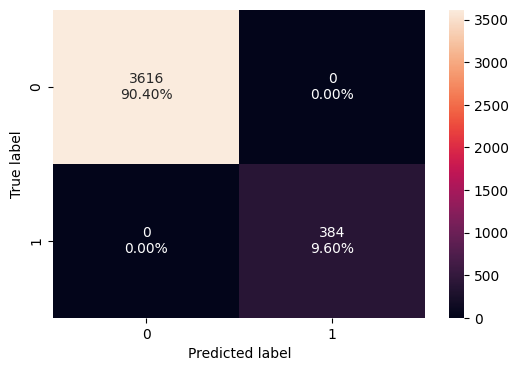

In [47]:
# plot confusion matrix for training set
confusion_matrix_sklearn(model0, X_train, y_train)

In [48]:
# performance metrics for training set
decision_tree_default_perf_train = model_performance_classification_sklearn(
    model0, X_train, y_train
)
decision_tree_default_perf_train

,Accuracy,Recall,Precision,F1
0,1.0,1.0,1.0,1.0


* The model gave perfect prediction on train data with 100% accuracy, recall and precision.

##### Model performance on Test set

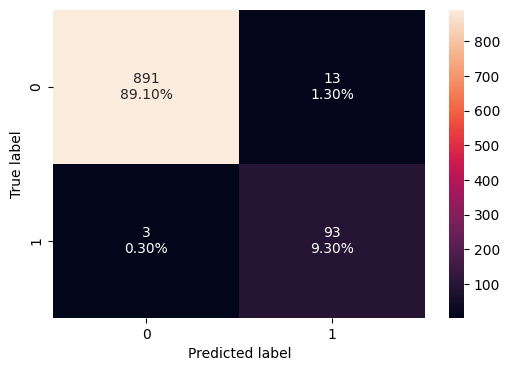

In [49]:
# plot confusion matrix for test set
confusion_matrix_sklearn(model0, X_test, y_test)

* 984 predictions are accurate in test set.
* 3 predictions are False Negatives and 13 predictions are False Positives.

In [50]:
# performance metrics for test set
decision_tree_default_perf_test = model_performance_classification_sklearn(
    model0, X_test, y_test
)
decision_tree_default_perf_test

,Accuracy,Recall,Precision,F1
0,0.984,0.96875,0.877358,0.920792


* The recall_score on training data is perfect (1.0) and lower (0.96) on test data indicating a sign of overfitting.
* Even though the model score is good on test data, it has perfectly memorized the training data including it's noise which is not preferred.

##### Visualizing the Decision Tree

In [51]:
# get feature names
column_names = list(X.columns)
feature_names = column_names
print(feature_names)

['Age', 'Income', 'Family', 'CCAvg', 'Education', 'Mortgage', 'Securities_Account', 'CD_Account', 'Online', 'CreditCard', 'County_92717', 'County_93077', 'County_96651', 'County_Alameda County', 'County_Butte County', 'County_Contra Costa County', 'County_El Dorado County', 'County_Fresno County', 'County_Humboldt County', 'County_Imperial County', 'County_Kern County', 'County_Lake County', 'County_Los Angeles County', 'County_Marin County', 'County_Mendocino County', 'County_Merced County', 'County_Monterey County', 'County_Napa County', 'County_Orange County', 'County_Placer County', 'County_Riverside County', 'County_Sacramento County', 'County_San Benito County', 'County_San Bernardino County', 'County_San Diego County', 'County_San Francisco County', 'County_San Joaquin County', 'County_San Luis Obispo County', 'County_San Mateo County', 'County_Santa Barbara County', 'County_Santa Clara County', 'County_Santa Cruz County', 'County_Shasta County', 'County_Siskiyou County', 'Count

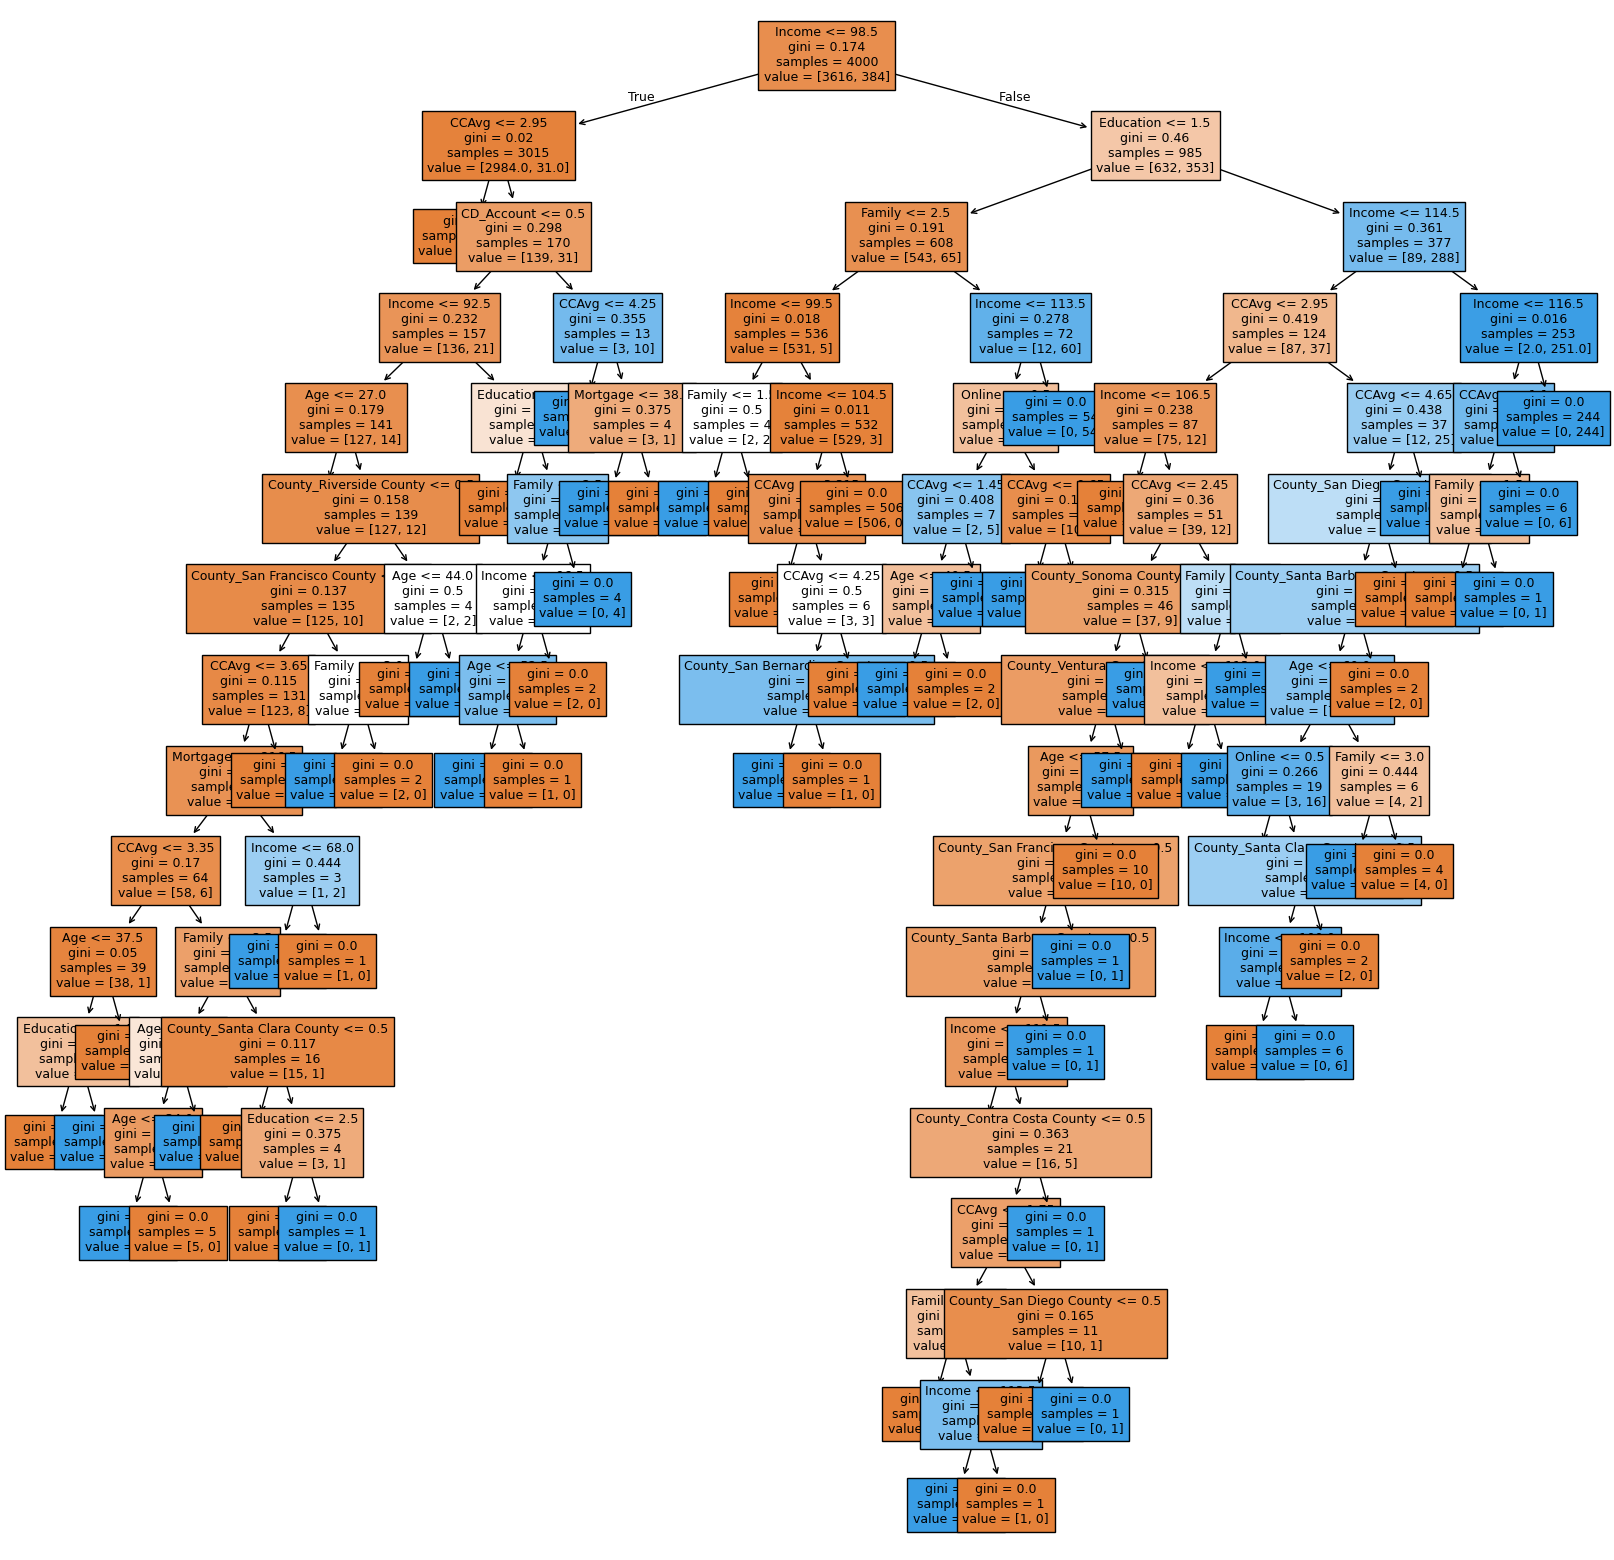

In [52]:
# list of feature names in X_train
feature_names = list(X_train.columns)

# set the figure size for the plot
plt.figure(figsize=(20, 20))

# plotting the decision tree
out = tree.plot_tree(
    model0,                         # decision tree classifier model
    feature_names=feature_names,    # list of feature names (columns) in the dataset
    filled=True,                    # fill the nodes with colors based on class
    fontsize=9,                     # font size for the node text
    node_ids=False,                 # do not show the ID of each node
    class_names=None,               # whether or not to display class names
)

# add arrows to the decision tree splits if they are missing
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")    # set arrow color to black
        arrow.set_linewidth(1)          # set arrow linewidth to 1

# displaying the plot
plt.show()

* This is a very complex tree.

In [53]:
# Text report showing the rules of a decision tree -

print(tree.export_text(model0, feature_names=feature_names, show_weights=True))

|--- Income <= 98.50
|   |--- CCAvg <= 2.95
|   |   |--- weights: [2845.00, 0.00] class: 0
|   |--- CCAvg >  2.95
|   |   |--- CD_Account <= 0.50
|   |   |   |--- Income <= 92.50
|   |   |   |   |--- Age <= 27.00
|   |   |   |   |   |--- weights: [0.00, 2.00] class: 1
|   |   |   |   |--- Age >  27.00
|   |   |   |   |   |--- County_Riverside County <= 0.50
|   |   |   |   |   |   |--- County_San Francisco County <= 0.50
|   |   |   |   |   |   |   |--- CCAvg <= 3.65
|   |   |   |   |   |   |   |   |--- Mortgage <= 216.50
|   |   |   |   |   |   |   |   |   |--- CCAvg <= 3.35
|   |   |   |   |   |   |   |   |   |   |--- Age <= 37.50
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |   |   |   |   |   |   |   |--- Age >  37.50
|   |   |   |   |   |   |   |   |   |   |   |--- weights: [36.00, 0.00] class: 0
|   |   |   |   |   |   |   |   |   |--- CCAvg >  3.35
|   |   |   |   |   |   |   |   |   |   |--- Family <= 3.50
|   |   |   |   |   |   |   

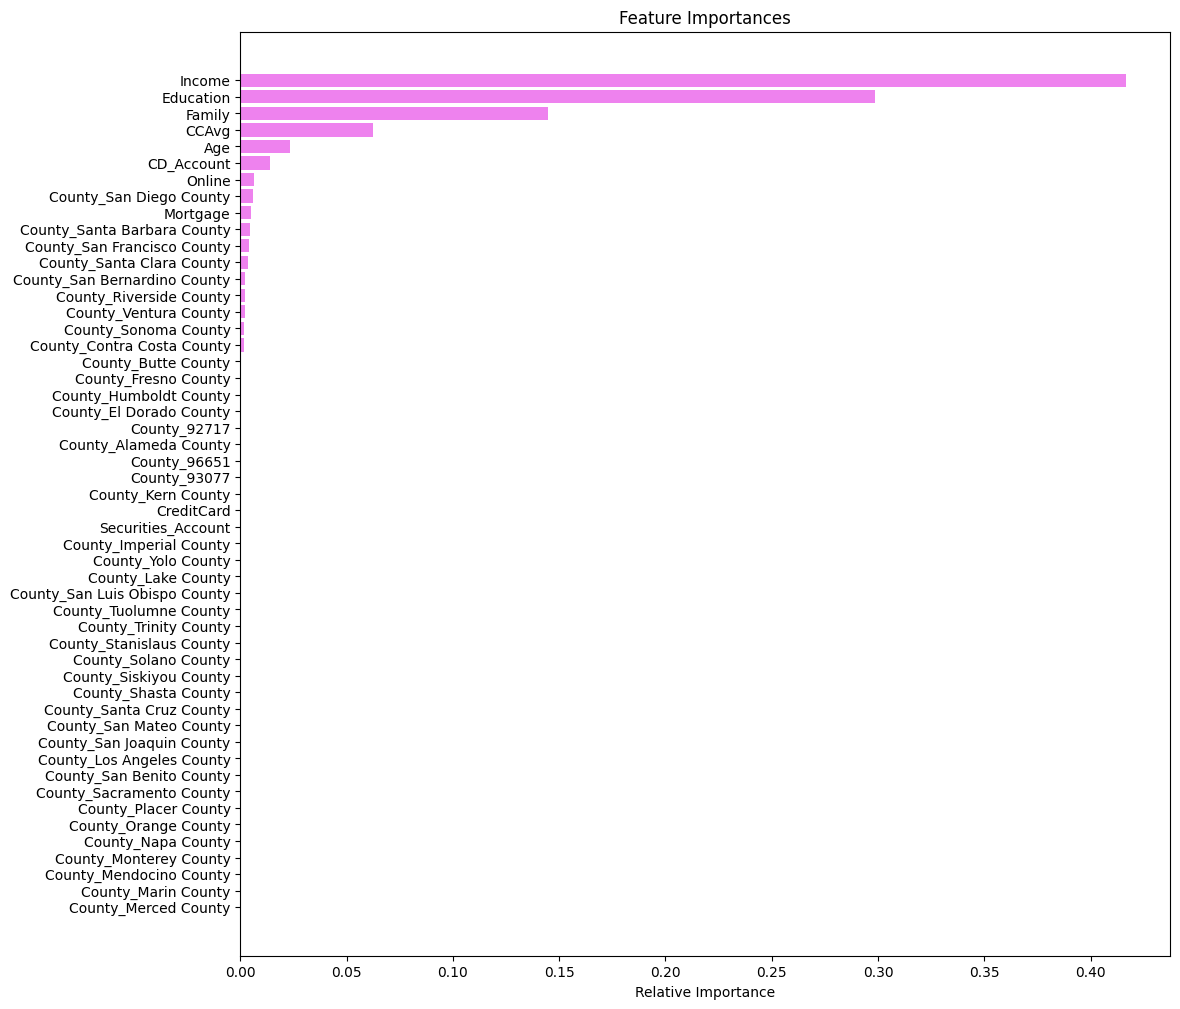

In [54]:
# plot feature importances
importances = model0.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

* **Income, Education and Family Size** are the top 3 important features.

## Model Performance Improvement

### Pre-Pruning

In [55]:
# Define the parameters of the tree to iterate over
max_depth_values = np.arange(6, 31, 3)
max_leaf_nodes_values = [50, 75, 150, 250]
min_samples_split_values = [10, 30, 50, 70]

# Initialize variables to store the best model and its performance
best_estimator = None
best_score_diff = float('inf')
best_test_score = 0.0

# Iterate over all combinations of the specified parameter values
for max_depth in max_depth_values:
    for max_leaf_nodes in max_leaf_nodes_values:
        for min_samples_split in min_samples_split_values:

            # Initialize the tree with the current set of parameters
            estimator = DecisionTreeClassifier(
                max_depth=max_depth,
                max_leaf_nodes=max_leaf_nodes,
                min_samples_split=min_samples_split,
                class_weight='balanced',
                random_state=42
            )

            # Fit the model to the training data
            estimator.fit(X_train, y_train)

            # Make predictions on the training and test sets
            y_train_pred = estimator.predict(X_train)
            y_test_pred = estimator.predict(X_test)

            # Calculate recall scores for training and test sets
            train_recall_score = recall_score(y_train, y_train_pred)
            test_recall_score = recall_score(y_test, y_test_pred)

            # Calculate the absolute difference between training and test recall scores
            score_diff = abs(train_recall_score - test_recall_score)

            # Update the best estimator and best score if the current one has a smaller score difference
            if (score_diff < best_score_diff) & (test_recall_score > best_test_score):
                best_score_diff = score_diff
                best_test_score = test_recall_score
                best_estimator = estimator

# creating an instance of the best model
model1 = best_estimator

# Print the best parameters
print("Best parameters found:")
print(f"Max depth: {best_estimator.max_depth}")
print(f"Max leaf nodes: {best_estimator.max_leaf_nodes}")
print(f"Min samples split: {best_estimator.min_samples_split}")
print(f"Best test recall score: {best_test_score}")

Best parameters found:
Max depth: 6
Max leaf nodes: 50
Min samples split: 10
Best test recall score: 0.9791666666666666


#### Checking pre-pruned model performance on train set

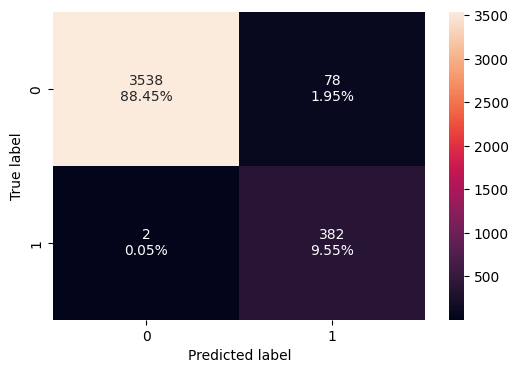

In [56]:
# plot confusion matrix for training set
confusion_matrix_sklearn(model1, X_train, y_train)

* False Negatives: 2
* False Positives: 78

In [57]:
# performance metrics for training set
decision_tree_tune_perf_train = model_performance_classification_sklearn(
    model1, X_train, y_train
)
decision_tree_tune_perf_train

,Accuracy,Recall,Precision,F1
0,0.98,0.994792,0.830435,0.905213


#### Checking Pre-pruned model performance on test set

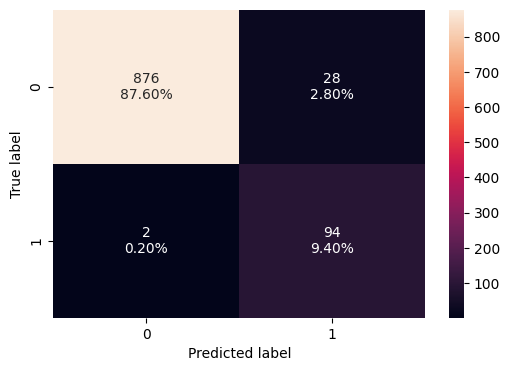

In [58]:
# plot confusion matrix for test set
confusion_matrix_sklearn(model1, X_test, y_test)

* False Negatives: 2
* False Positives: 28

In [59]:
# performance metrics for test set
decision_tree_tune_perf_test = model_performance_classification_sklearn(
    model1, X_test, y_test
)

decision_tree_tune_perf_test

,Accuracy,Recall,Precision,F1
0,0.97,0.979167,0.770492,0.862385


* Recall_score imporved slightly on test set compared to initial default model.

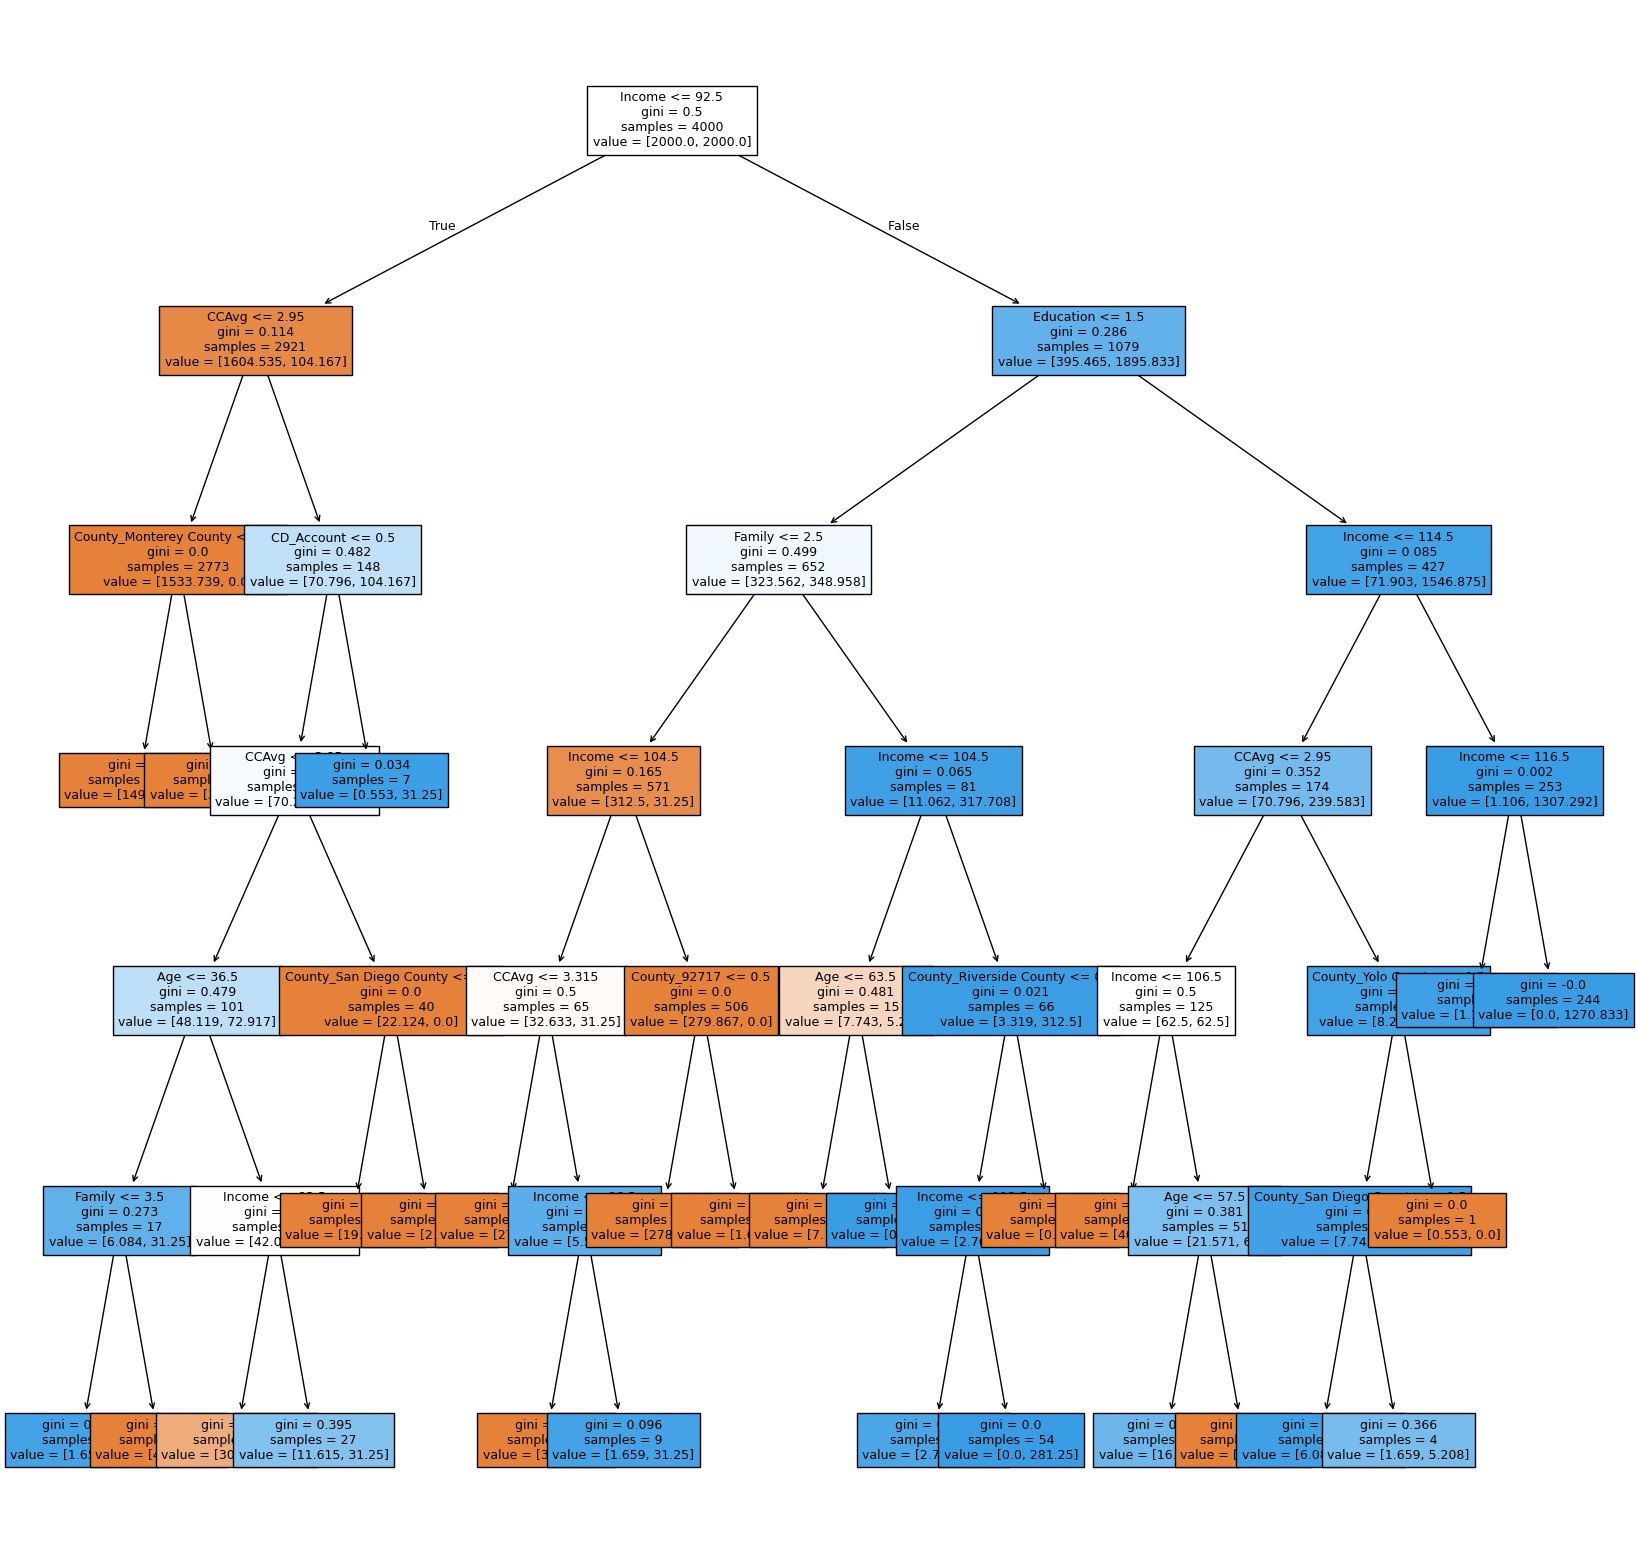

In [60]:
# list of feature names in X_train
feature_names = list(X_train.columns)

# set the figure size for the plot
plt.figure(figsize=(20, 20))

# plotting the decision tree
out = tree.plot_tree(
    model1,                         # decision tree classifier model
    feature_names=feature_names,    # list of feature names (columns) in the dataset
    filled=True,                    # fill the nodes with colors based on class
    fontsize=9,                     # font size for the node text
    node_ids=False,                 # do not show the ID of each node
    class_names=None,               # whether or not to display class names
)

# add arrows to the decision tree splits if they are missing
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")    # set arrow color to black
        arrow.set_linewidth(1)          # set arrow linewidth to 1

# displaying the plot
plt.show()

* We have a simplified tree after pre-pruning.

In [61]:
# Text report showing the rules of a decision tree -

print(tree.export_text(model1, feature_names=feature_names, show_weights=True))

|--- Income <= 92.50
|   |--- CCAvg <= 2.95
|   |   |--- County_Monterey County <= 0.50
|   |   |   |--- weights: [1496.13, 0.00] class: 0
|   |   |--- County_Monterey County >  0.50
|   |   |   |--- weights: [37.61, 0.00] class: 0
|   |--- CCAvg >  2.95
|   |   |--- CD_Account <= 0.50
|   |   |   |--- CCAvg <= 3.95
|   |   |   |   |--- Age <= 36.50
|   |   |   |   |   |--- Family <= 3.50
|   |   |   |   |   |   |--- weights: [1.66, 31.25] class: 1
|   |   |   |   |   |--- Family >  3.50
|   |   |   |   |   |   |--- weights: [4.42, 0.00] class: 0
|   |   |   |   |--- Age >  36.50
|   |   |   |   |   |--- Income <= 82.50
|   |   |   |   |   |   |--- weights: [30.42, 10.42] class: 0
|   |   |   |   |   |--- Income >  82.50
|   |   |   |   |   |   |--- weights: [11.62, 31.25] class: 1
|   |   |   |--- CCAvg >  3.95
|   |   |   |   |--- County_San Diego County <= 0.50
|   |   |   |   |   |--- weights: [19.91, 0.00] class: 0
|   |   |   |   |--- County_San Diego County >  0.50
|   |   |   |

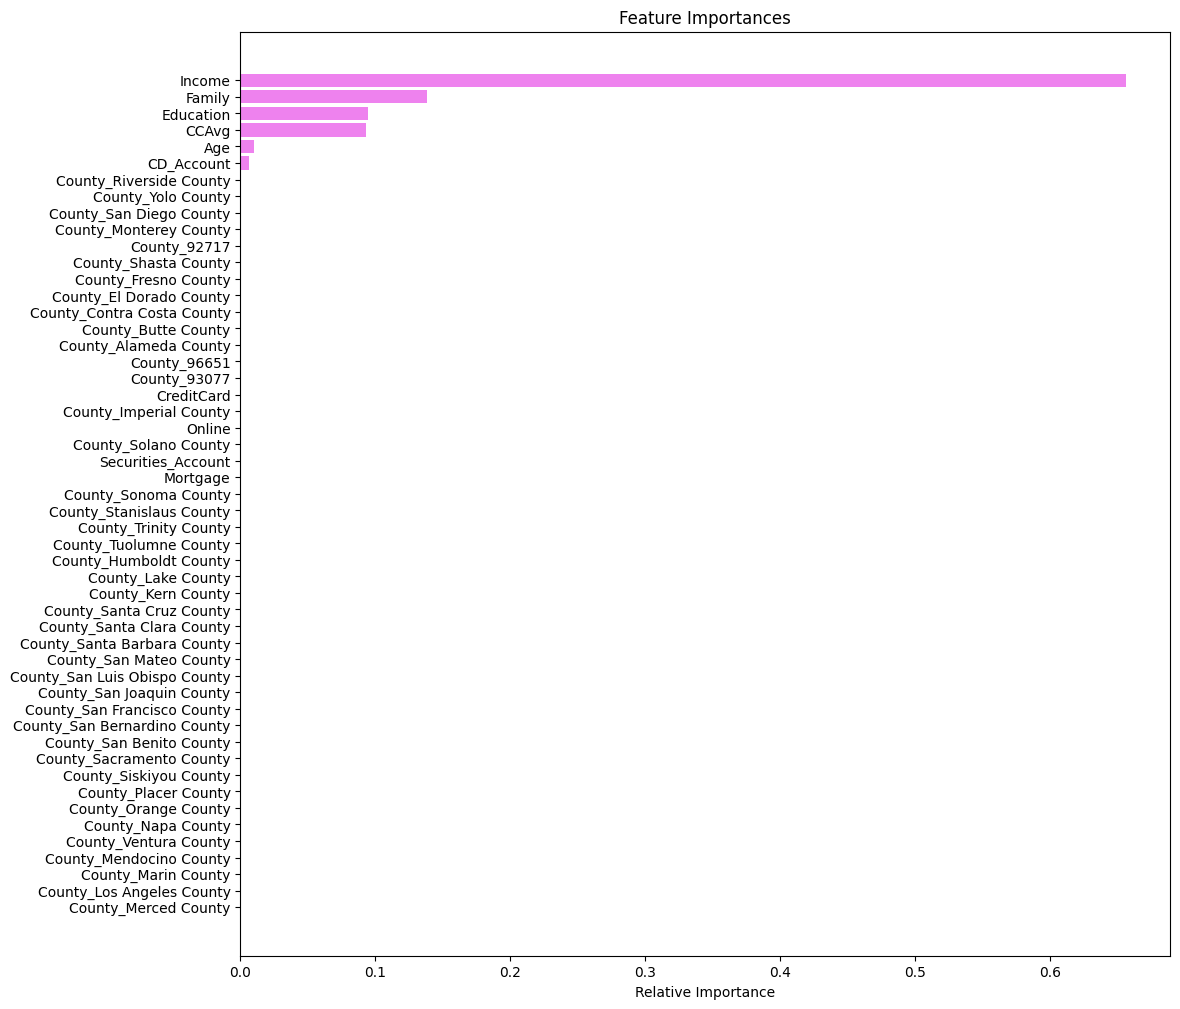

In [62]:
# plot feature importances
importances = model1.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

* Income still remains the top important feature.
* Family size became the second important feature in this case.
* Education and CCAvg got almost similar importance.

### Post Pruning - Cost Complexity Pruning

In [63]:
# Create an instance of the decision tree model
clf = DecisionTreeClassifier(random_state=42)

# Compute the cost complexity pruning path for the model using the training data
path = clf.cost_complexity_pruning_path(X_train, y_train)

# Extract the array of effective alphas from the pruning path
ccp_alphas = abs(path.ccp_alphas)

# Extract the array of total impurities at each alpha along the pruning path
impurities = path.impurities

In [64]:
pd.DataFrame(path)

,ccp_alphas,impurities
0,0.000000,0.000000
1,0.000234,0.000469
2,0.000244,0.000956
3,0.000300,0.001556
4,0.000327,0.004499
5,0.000331,0.005491
6,0.000333,0.005825
7,0.000333,0.006158
8,0.000338,0.006834
9,0.000350,0.007884


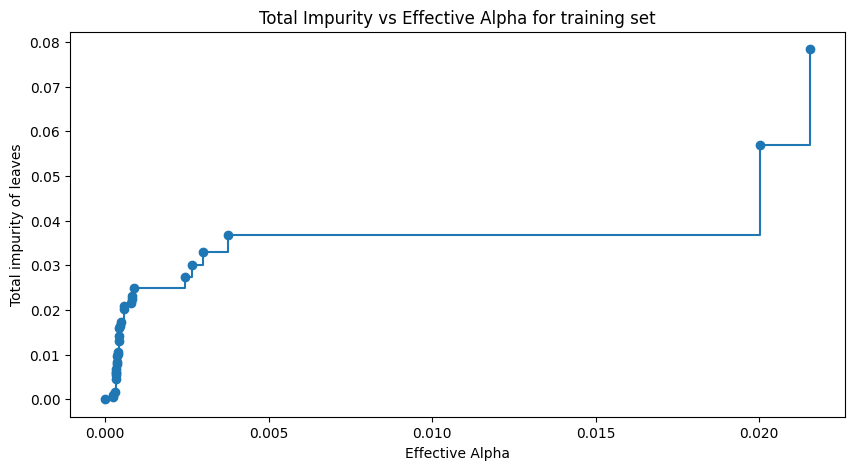

In [65]:
# Create a figure
fig, ax = plt.subplots(figsize=(10, 5))

# Plot the total impurities versus effective alphas, excluding the last value,
# using markers at each data point and connecting them with steps
ax.plot(ccp_alphas[:-1], impurities[:-1], marker="o", drawstyle="steps-post")

# Set the x-axis label
ax.set_xlabel("Effective Alpha")

# Set the y-axis label
ax.set_ylabel("Total impurity of leaves")

# Set the title of the plot
ax.set_title("Total Impurity vs Effective Alpha for training set");

* Next, we train a decision tree using the effective alphas.

* The last value in `ccp_alphas` is the alpha value that prunes the whole tree,
leaving the corresponding tree with one node.

In [66]:
# Initialize an empty list to store the decision tree classifiers
clfs = []

# Iterate over each ccp_alpha value extracted from cost complexity pruning path
for ccp_alpha in ccp_alphas:
    # Create an instance of the DecisionTreeClassifier
    clf = DecisionTreeClassifier(ccp_alpha=ccp_alpha, random_state=42)

    # Fit the classifier to the training data
    clf.fit(X_train, y_train)

    # Append the trained classifier to the list
    clfs.append(clf)

# Print the number of nodes in the last tree along with its ccp_alpha value
print(
    "Number of nodes in the last tree is {} with ccp_alpha {}".format(
        clfs[-1].tree_.node_count, ccp_alphas[-1]
    )
)

Number of nodes in the last tree is 1 with ccp_alpha 0.04760359071815694


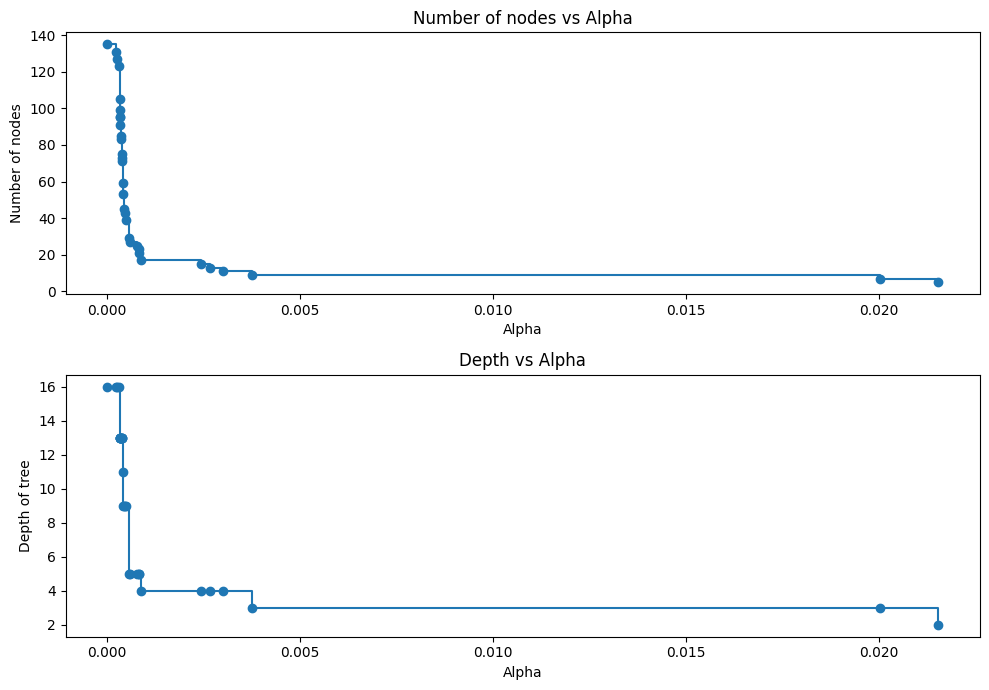

In [67]:
# Remove the last classifier and corresponding ccp_alpha value from the lists
clfs = clfs[:-1]
ccp_alphas = ccp_alphas[:-1]

# Extract the number of nodes in each tree classifier
node_counts = [clf.tree_.node_count for clf in clfs]

# Extract the maximum depth of each tree classifier
depth = [clf.tree_.max_depth for clf in clfs]

# Create a figure and a set of subplots
fig, ax = plt.subplots(2, 1, figsize=(10, 7))

# Plot the number of nodes versus ccp_alphas on the first subplot
ax[0].plot(ccp_alphas, node_counts, marker="o", drawstyle="steps-post")
ax[0].set_xlabel("Alpha")
ax[0].set_ylabel("Number of nodes")
ax[0].set_title("Number of nodes vs Alpha")

# Plot the depth of tree versus ccp_alphas on the second subplot
ax[1].plot(ccp_alphas, depth, marker="o", drawstyle="steps-post")
ax[1].set_xlabel("Alpha")
ax[1].set_ylabel("Depth of tree")
ax[1].set_title("Depth vs Alpha")

# Adjust the layout of the subplots to avoid overlap
fig.tight_layout()

#### Recall vs alpha for training and testing sets

In [68]:
# Calculate recall scores for each classifier on the training set
recall_train = []
for clf in clfs:
    pred_train = clf.predict(X_train)
    values_train = recall_score(y_train, pred_train)
    recall_train.append(values_train)

In [69]:
# Calculate recall scores for each classifier on the test set
recall_test = []
for clf in clfs:
    pred_test = clf.predict(X_test)
    values_test = recall_score(y_test, pred_test)
    recall_test.append(values_test)

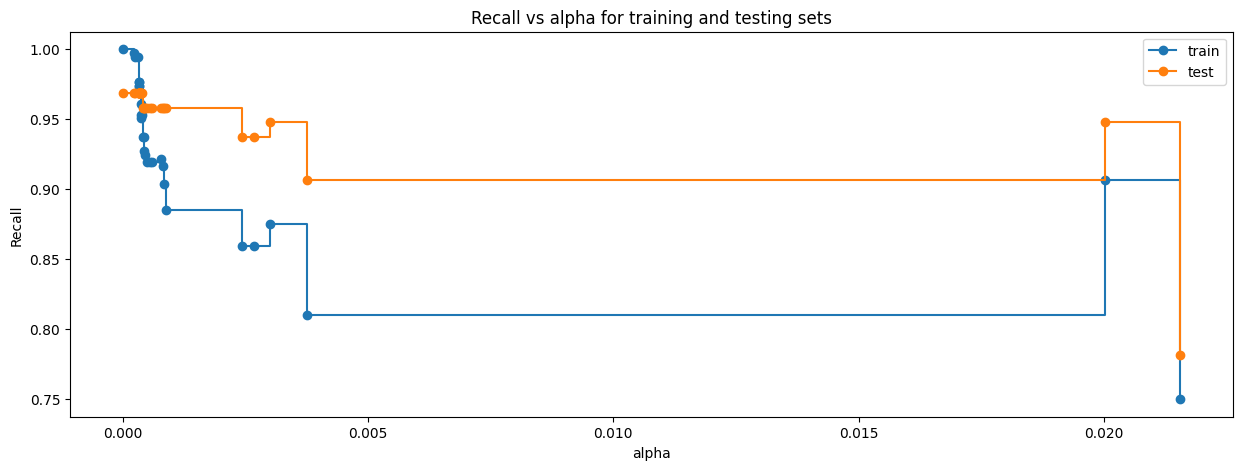

In [70]:
# Create a figure and axis for plotting
fig, ax = plt.subplots(figsize=(15, 5))
ax.set_xlabel("alpha")
ax.set_ylabel("Recall")
ax.set_title("Recall vs alpha for training and testing sets")

# Plot recall scores for training and test sets
ax.plot(ccp_alphas, recall_train, marker="o", label="train", drawstyle="steps-post")
ax.plot(ccp_alphas, recall_test, marker="o", label="test", drawstyle="steps-post")
ax.legend()
plt.show()

* We are getting a balanced higher recall_score for both train and test sets at alpha value of ~0.0008

In [71]:
# creating the model with alpha value 0.0008
model3 = DecisionTreeClassifier(ccp_alpha=0.0008, random_state=42)
model3.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


#### Checking model performance on training set

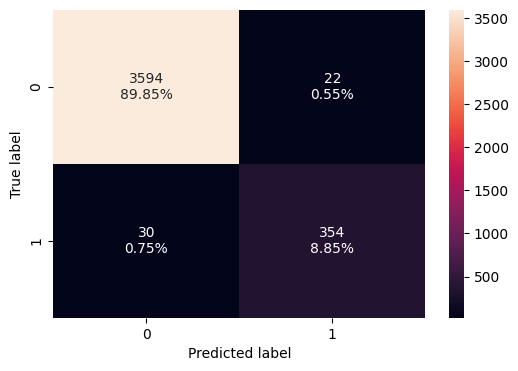

In [72]:
# plot confusion matrix for training set
confusion_matrix_sklearn(model3, X_train, y_train)

* False Negatives: 30
* False Positives: 22

In [73]:
# performance metrics for training set
decision_tree_postpruned_perf_train = model_performance_classification_sklearn(
    model3, X_train, y_train
)
decision_tree_postpruned_perf_train

,Accuracy,Recall,Precision,F1
0,0.987,0.921875,0.941489,0.931579


* The model generalized better on training set compared to other models.

#### Checking model performance on test set

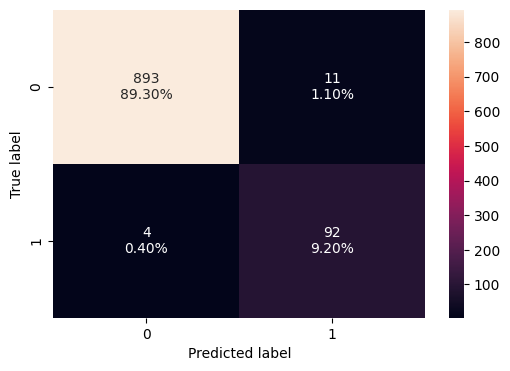

In [74]:
# plot confusion matrix for test set
confusion_matrix_sklearn(model3, X_test, y_test)

* False Negatives: 4
* False Positives: 11

In [75]:
# performance metrics for test set
decision_tree_postpruned_perf_test = model_performance_classification_sklearn(
    model3, X_test, y_test
)
decision_tree_postpruned_perf_test

,Accuracy,Recall,Precision,F1
0,0.985,0.958333,0.893204,0.924623


* There is not much difference in the recall_score as compared to the pre-pruned model. But the precision_score improved a lot.

#### Visualize the Decision Tree

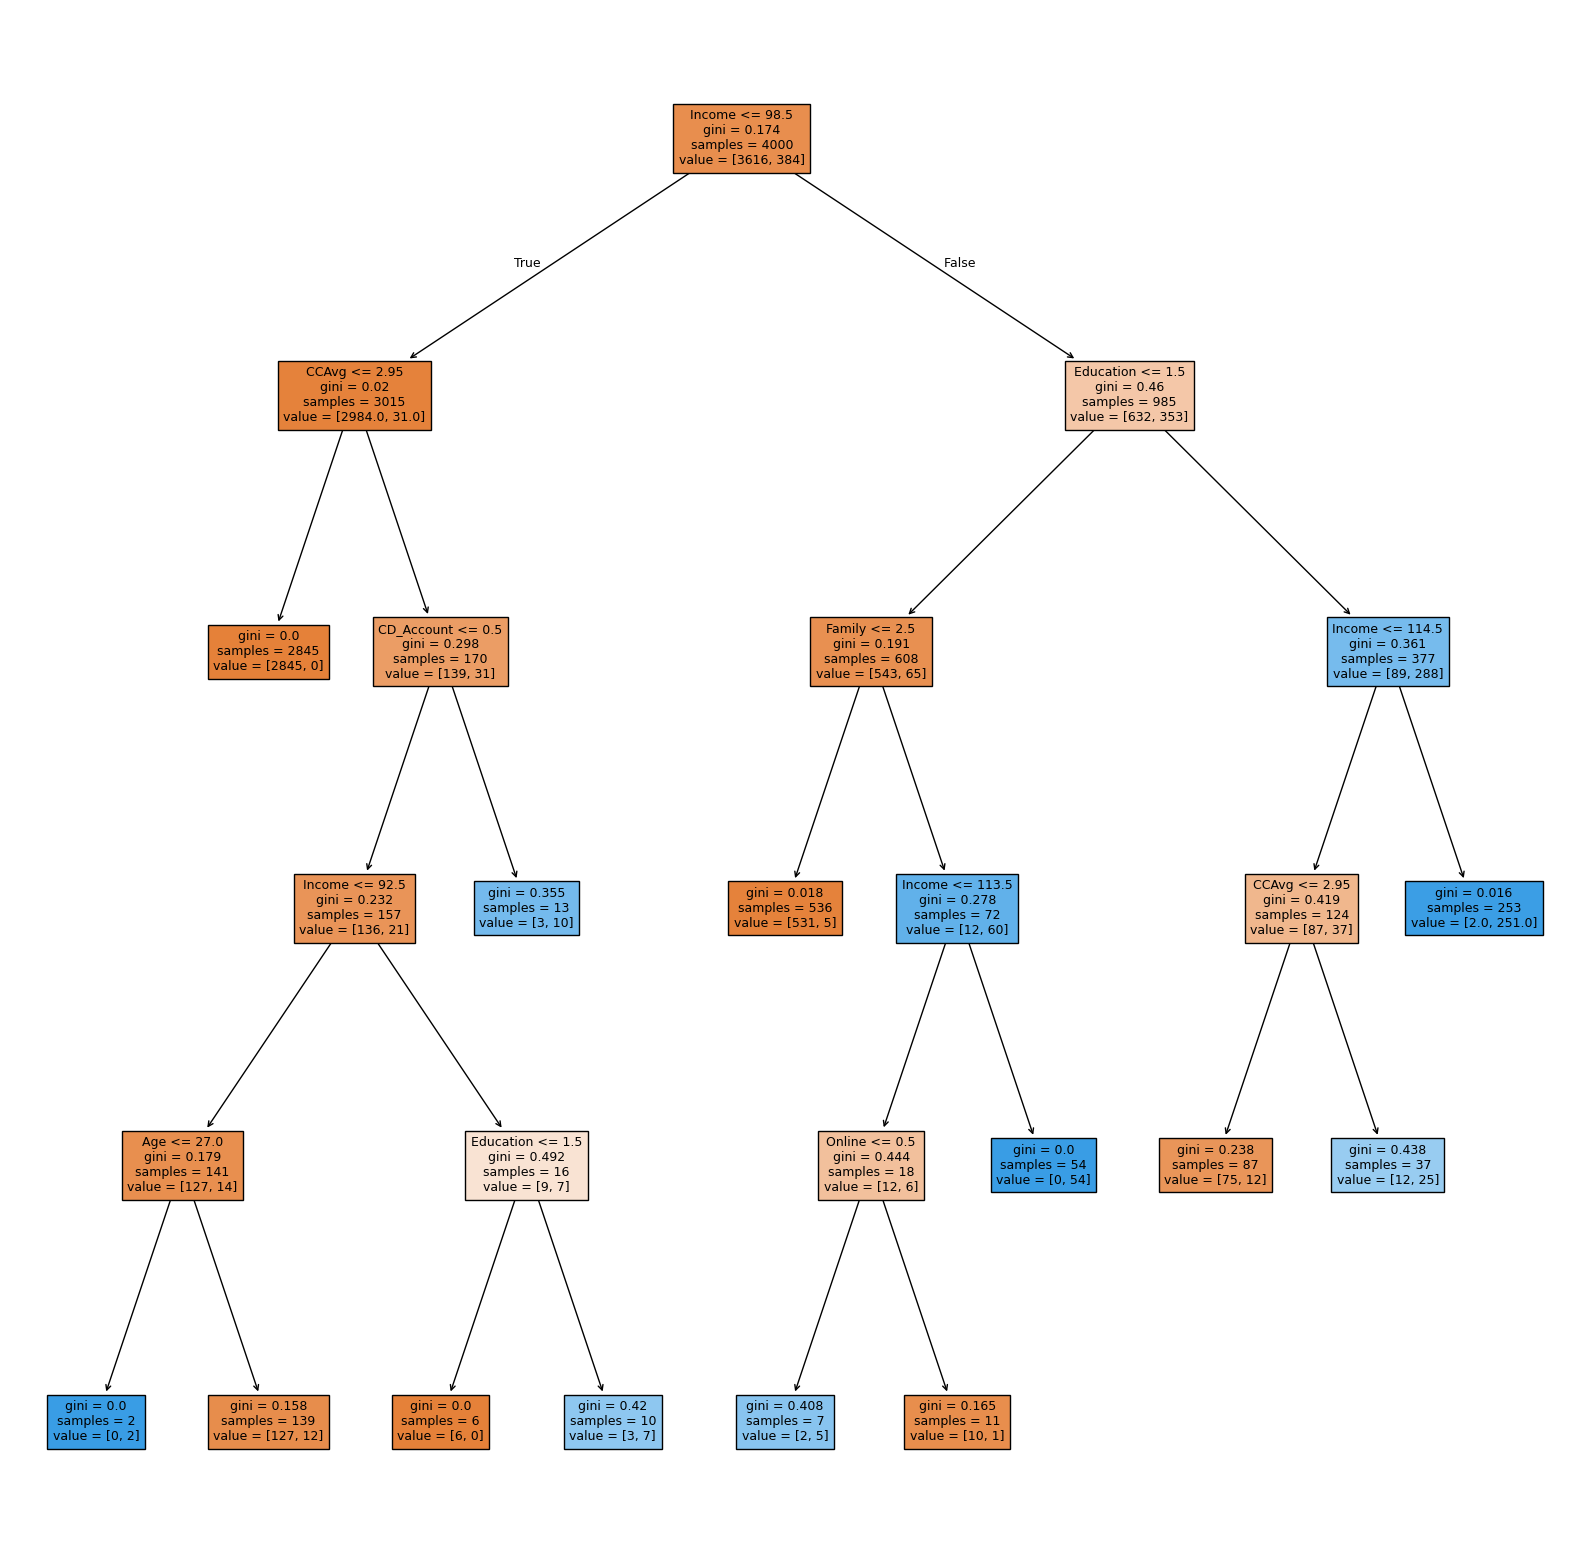

In [76]:
# list of feature names in X_train
feature_names = list(X_train.columns)

# set the figure size for the plot
plt.figure(figsize=(20, 20))

# plotting the decision tree
out = tree.plot_tree(
    model3,                         # decision tree classifier model
    feature_names=feature_names,    # list of feature names (columns) in the dataset
    filled=True,                    # fill the nodes with colors based on class
    fontsize=9,                     # font size for the node text
    node_ids=False,                 # do not show the ID of each node
    class_names=None,               # whether or not to display class names
)

# add arrows to the decision tree splits if they are missing
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")    # set arrow color to black
        arrow.set_linewidth(1)          # set arrow linewidth to 1

# displaying the plot
plt.show()

* This tree is the simplest compared to default and pre-pruned model trees.

In [77]:
# Text report showing the rules of a decision tree -

print(tree.export_text(model3, feature_names=feature_names, show_weights=True))

|--- Income <= 98.50
|   |--- CCAvg <= 2.95
|   |   |--- weights: [2845.00, 0.00] class: 0
|   |--- CCAvg >  2.95
|   |   |--- CD_Account <= 0.50
|   |   |   |--- Income <= 92.50
|   |   |   |   |--- Age <= 27.00
|   |   |   |   |   |--- weights: [0.00, 2.00] class: 1
|   |   |   |   |--- Age >  27.00
|   |   |   |   |   |--- weights: [127.00, 12.00] class: 0
|   |   |   |--- Income >  92.50
|   |   |   |   |--- Education <= 1.50
|   |   |   |   |   |--- weights: [6.00, 0.00] class: 0
|   |   |   |   |--- Education >  1.50
|   |   |   |   |   |--- weights: [3.00, 7.00] class: 1
|   |   |--- CD_Account >  0.50
|   |   |   |--- weights: [3.00, 10.00] class: 1
|--- Income >  98.50
|   |--- Education <= 1.50
|   |   |--- Family <= 2.50
|   |   |   |--- weights: [531.00, 5.00] class: 0
|   |   |--- Family >  2.50
|   |   |   |--- Income <= 113.50
|   |   |   |   |--- Online <= 0.50
|   |   |   |   |   |--- weights: [2.00, 5.00] class: 1
|   |   |   |   |--- Online >  0.50
|   |   |   |   | 

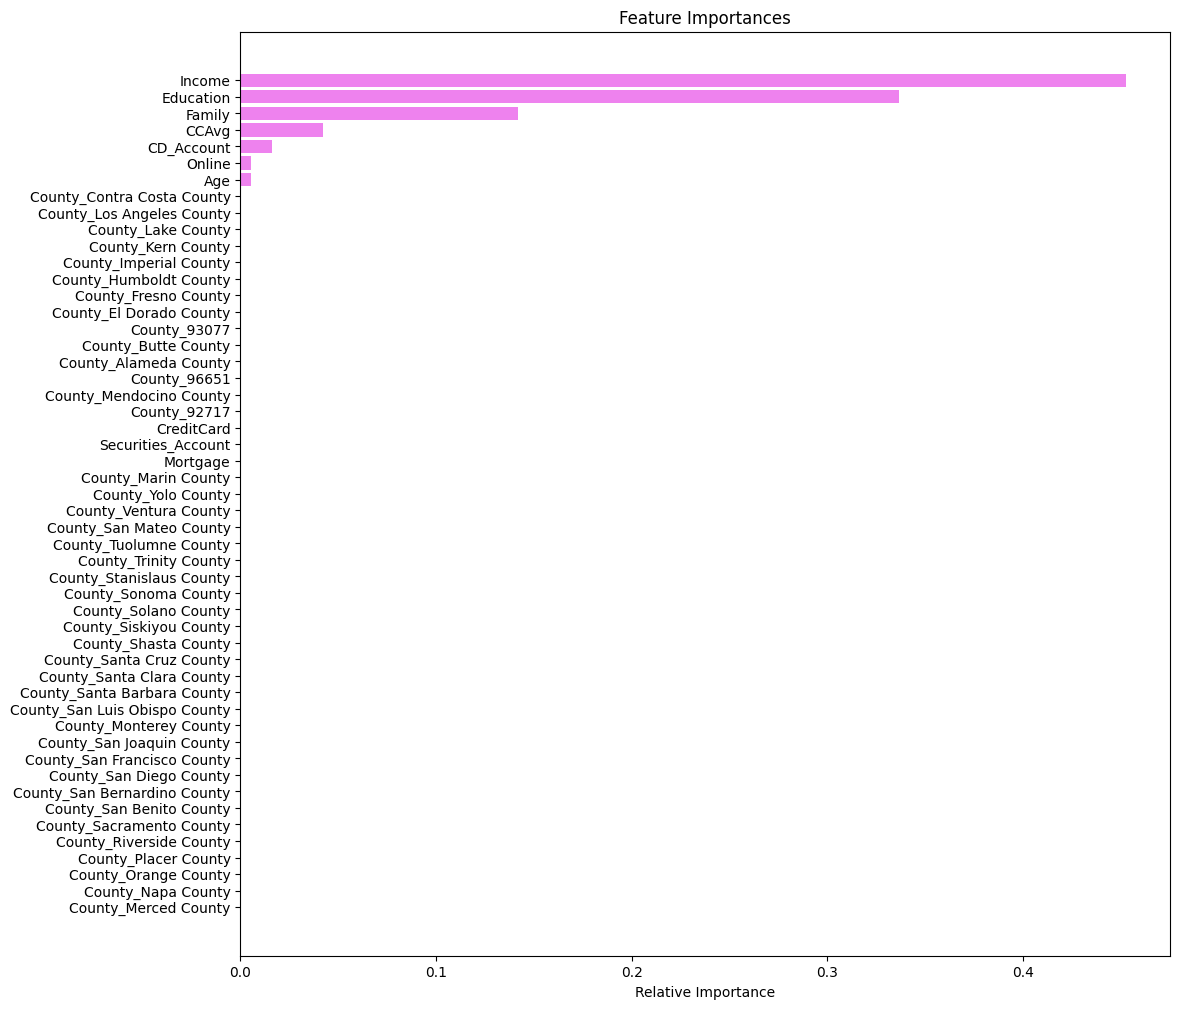

In [78]:
# plot feature importances
importances = model3.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

* Income, Education and Family size remain the top important features as in the default model.

## Model Performance Comparison and Final Model Selection

In [79]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        decision_tree_default_perf_train.T,
        decision_tree_tune_perf_train.T,
        decision_tree_postpruned_perf_train.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Decision Tree (sklearn default)",
    "Decision Tree (Pre-Pruning)",
    "Decision Tree (Post-Pruning)",
]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Decision Tree (sklearn default),Decision Tree (Pre-Pruning),Decision Tree (Post-Pruning)
Accuracy,1.0,0.980000,0.987000
Recall,1.0,0.994792,0.921875
Precision,1.0,0.830435,0.941489
F1,1.0,0.905213,0.931579


* Post-pruned model generalized well on the training data set.

In [80]:
# test performance comparison

models_train_comp_df = pd.concat(
    [
        decision_tree_default_perf_test.T,
        decision_tree_tune_perf_test.T,
        decision_tree_postpruned_perf_test.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Decision Tree (sklearn default)",
    "Decision Tree (Pre-Pruning)",
    "Decision Tree (Post-Pruning)",
]
print("Test set performance comparison:")
models_train_comp_df

Test set performance comparison:


,Decision Tree (sklearn default),Decision Tree (Pre-Pruning),Decision Tree (Post-Pruning)
Accuracy,0.984000,0.970000,0.985000
Recall,0.968750,0.979167,0.958333
Precision,0.877358,0.770492,0.893204
F1,0.920792,0.862385,0.924623


* Decision Tree with pre-pruning has the highest recall_score on test set.
* However, Decision Tree with post-pruning has almost similar recall_score but with improved accuracy and precision scores finding the balance. 
* Post-pruned tree is the simplest among all. 
* Therefore, we can proceed with post-pruned model as our final model.

## Actionable Insights and Business Recommendations


* What recommedations would you suggest to the bank?

    - **Target High-Income Customers:**
    Customers with higher annual incomes are significantly more likely to accept personal loan offers. Focus marketing efforts on this segment.

    - **Leverage Credit Card Spending Data:**
    Customers with higher average monthly credit card spending are more receptive to personal loans. Use this as a key targeting criterion.

    - **Promote Loans to CD Account Holders:**
    Customers with a Certificate of Deposit (CD) account have a much higher loan acceptance rate (~50%). Prioritize them for cross-selling.

    - **Focus on Educated Segments:**
    Customers with higher education levels (Graduate and Advanced/Professional) show greater interest in personal loans. Tailor campaigns for these groups.

    - **Consider Family Size:**
    Families with 3 or 4 members are more likely to accept loans. Segment offers accordingly.

    - **Geographic Targeting:**
    Certain counties (e.g., Sonoma, Shasta, San Luis Obispo) have higher loan acceptance rates. Allocate more resources to these regions.

    - **Simplify Product Offerings:**
    Since online banking and external credit card ownership do not significantly impact loan acceptance, focus less on these features in marketing.

    - **Use Pruned Decision Trees for Prediction:**
    The post-pruned decision tree model balances recall and precision, making it suitable for identifying potential loan customers while minimizing both false negatives and false positives.

___